In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

DATA_FILE = 'csd_cleaned.csv'

In [3]:
df = pd.read_csv(DATA_FILE, low_memory=False)

In [4]:
print(f"{len(df):,} lignes — {len(df.columns)} colonnes\n")
for col in df.columns:
    pct = df[col].notna().mean() * 100
    examples = df[col].dropna().unique()[:3]
    ex_str = ' | '.join(repr(e) for e in examples)
    print(f"  {col:<35} {pct:5.1f}%   ex: {ex_str}")

339,179 lignes — 44 colonnes

  identifier                          100.0%   ex: 'AABHTZ' | 'AACFAZ10' | 'AACMHX10'
  is_organic                          100.0%   ex: True
  has_metal                           100.0%   ex: False
  num_components                      100.0%   ex: 1
  has_disorder                        100.0%   ex: False | True
  disorder_details                     12.9%   ex: 'The cyclohexene ring is disordered over two sites with occupancies 0.5878:0.4122.' | 'O4 and O4A disordered over two sites with occupancies 0.578:0.422.' | 'A methyl group is disordered over two sites with occupancies 0.70:0.30.'
  color                                85.2%   ex: 'red' | 'colorless' | 'yellow'
  color_clean                          85.2%   ex: 'red' | 'colorless' | 'yellow'
  polymorph                             3.9%   ex: 'monoclinic P21/c polymorph' | 'orthorhombic P212121 polymorph' | 'polymorph II'
  phase_transition                      0.3%   ex: 'irreversible phase trans

## Identifier columns — no analysis

In [5]:
ID_COLS = ['identifier', 'ccdc_number', 'doi', 'publications', 'inchi', 'smiles']

descriptions = {
    'identifier':   'unique CSD code',
    'ccdc_number':  'CCDC number',
    'doi':          'link to publication',
    'publications': 'full parsed citation',
    'inchi':        'InChI chemical identifier',
    'smiles':       'molecular structure SMILES',
}

print("Columns excluded from analysis (identifiers / links):\n")
for col in ID_COLS:
    pct = df[col].notna().mean() * 100
    ex = repr(df[col].dropna().iloc[0])
    print(f"  {col:<20} {pct:5.1f}% filled   — {descriptions[col]}")
    print(f"  {'':20}   ex: {ex[:80]}{'...' if len(ex) > 80 else ''}")
    print()

Columns excluded from analysis (identifiers / links):

  identifier           100.0% filled   — unique CSD code
                         ex: 'AABHTZ'

  ccdc_number          100.0% filled   — CCDC number
                         ex: 1100001

  doi                   85.8% filled   — link to publication
                         ex: '10.5517/cc85q15'

  publications         100.0% filled   — full parsed citation
                         ex: "Citation(authors='P.-E.Werner', journal='Journal(Crystal Structure Communicatio...

  inchi                100.0% filled   — InChI chemical identifier
                         ex: 'InChI=1S/C13H12Cl2N6O2/c1-8(22)19-20-7-16-18-13(20)21(9(2)23)17-6-10-11(14)4-3-...

  smiles               100.0% filled   — molecular structure SMILES
                         ex: 'CC(=O)NN1C=NN=C1N(N=Cc1c(Cl)cccc1Cl)C(C)=O'



## Boolean columns

In [6]:
BOOL_COLS = ['is_organic', 'has_metal', 'has_disorder']

for col in BOOL_COLS:
    n = len(df)
    n_true  = df[col].sum()
    n_false = (df[col] == False).sum()
    print(f"  {col:<20}  True: {n_true:>9,} ({n_true/n*100:5.1f}%)   False: {n_false:>9,} ({n_false/n*100:5.1f}%)")

  is_organic            True:   339,179 (100.0%)   False:         0 (  0.0%)
  has_metal             True:         0 (  0.0%)   False:   339,179 (100.0%)
  has_disorder          True:    43,614 ( 12.9%)   False:   295,565 ( 87.1%)


In [7]:
mask = df['is_organic'] & ~df['has_metal'] & (df['num_components'] == 1)
n_kept = mask.sum()
n_total = len(df)
print(f"Filter: is_organic=True, has_metal=False, num_components=1")
print(f"  Kept : {n_kept:>9,} / {n_total:,} ({n_kept/n_total*100:.1f}%)")
print(f"  Dropped: {n_total - n_kept:>9,} ({(n_total - n_kept)/n_total*100:.1f}%)")

Filter: is_organic=True, has_metal=False, num_components=1
  Kept :   339,179 / 339,179 (100.0%)
  Dropped:         0 (0.0%)


## Numeric columns

### Molecular properties

#### `calculated_density`

count    339179.000
mean          1.368
std           0.222
min           0.264
25%           1.243
50%           1.328
75%           1.438
max          26.831

Missing: 0 (0.0%)


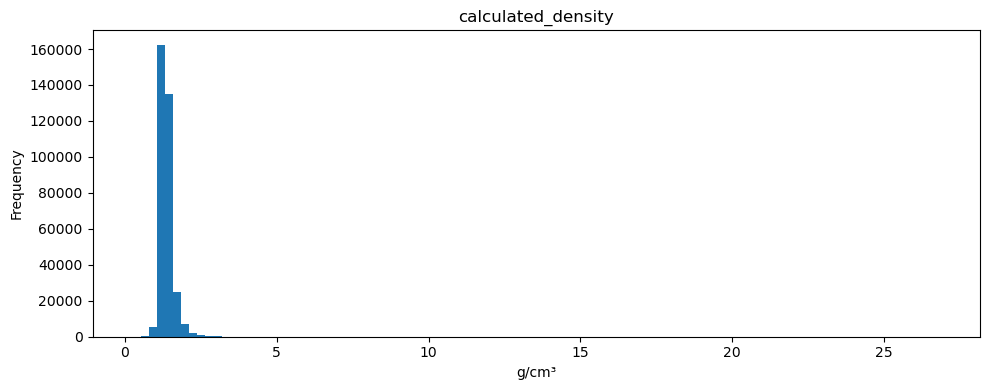

In [8]:
col = 'calculated_density'
print(df[col].describe().round(3).to_string())
print(f"\nMissing: {df[col].isna().sum():,} ({df[col].isna().mean()*100:.1f}%)")

df[col].dropna().plot.hist(bins=100, figsize=(10, 4))
plt.title('calculated_density')
plt.xlabel('g/cm³')
plt.tight_layout()
plt.show()

99th   percentile : 2.151 g/cm³
99.9th percentile : 3.042 g/cm³
Values above p99  : 3,389 (1.00%)

Histogram peak    : 1.292 g/cm³


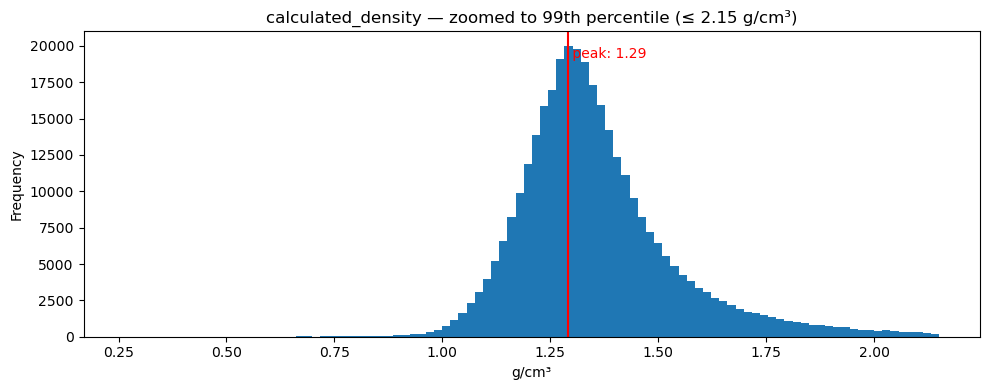

In [9]:
col = 'calculated_density'
s = df[col].dropna()

p99 = s.quantile(0.99)
p999 = s.quantile(0.999)
print(f"99th   percentile : {p99:.3f} g/cm³")
print(f"99.9th percentile : {p999:.3f} g/cm³")
print(f"Values above p99  : {(s > p99).sum():,} ({(s > p99).mean()*100:.2f}%)")

s_zoom = s[s <= p99]
counts, edges = np.histogram(s_zoom, bins=100)
peak = (edges[counts.argmax()] + edges[counts.argmax() + 1]) / 2
print(f"\nHistogram peak    : {peak:.3f} g/cm³")

fig, ax = plt.subplots(figsize=(10, 4))
s_zoom.plot.hist(bins=100, ax=ax)
ax.axvline(peak, color='red', linewidth=1.5)
ax.text(peak, ax.get_ylim()[1] * 0.95, f' peak: {peak:.2f}', color='red', va='top')
ax.set_title(f'calculated_density — zoomed to 99th percentile (≤ {p99:.2f} g/cm³)')
ax.set_xlabel('g/cm³')
plt.tight_layout()
plt.show()

#### `molecular_weight`

count    339179.000
mean        394.355
std         202.819
min          10.811
25%         280.160
50%         356.262
75%         456.575
max        7352.585

Missing: 0 (0.0%)

Largest molecule (by weight):
  identifier       : BAFDOG
  molecular_weight : 7352.6 g/mol
  molecular_volume : 6639.0 Å³


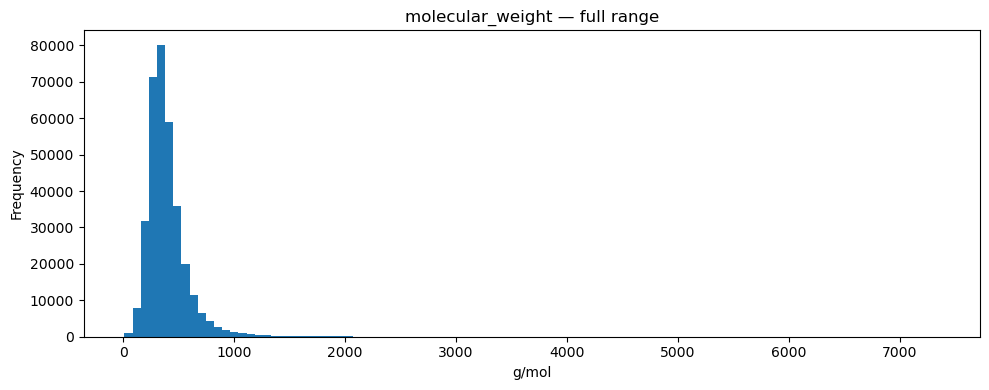

In [10]:
col = 'molecular_weight'
s = df[col].dropna()

print(s.describe().round(3).to_string())
print(f"\nMissing: {df[col].isna().sum():,} ({df[col].isna().mean()*100:.1f}%)")

idx_max = s.idxmax()
row_max = df.loc[idx_max]
print(f"\nLargest molecule (by weight):")
print(f"  identifier       : {row_max['identifier']}")
print(f"  molecular_weight : {row_max['molecular_weight']:.1f} g/mol")
print(f"  molecular_volume : {row_max['molecular_volume']:.1f} Å³")

s.plot.hist(bins=100, figsize=(10, 4))
plt.title('molecular_weight — full range')
plt.xlabel('g/mol')
plt.tight_layout()
plt.show()

99th   percentile : 1132.479 g/mol
99.9th percentile : 2115.633 g/mol
Values above p99  : 3,392 (1.00%)

Histogram peak    : 319 g/mol


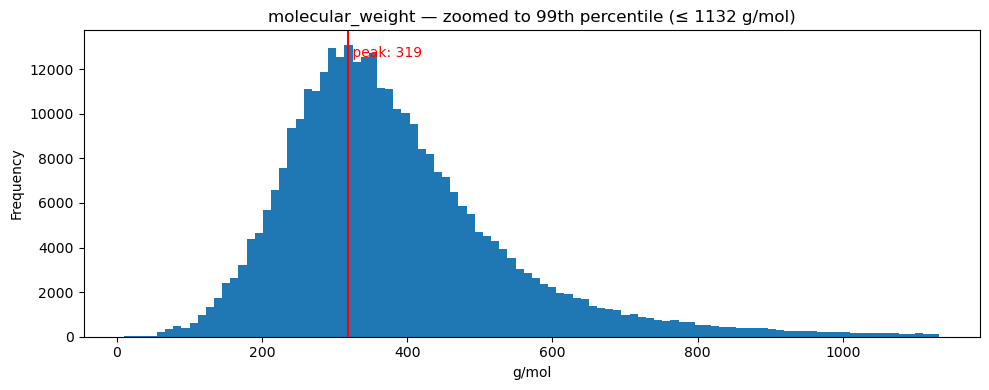

In [11]:
col = 'molecular_weight'
s = df[col].dropna()

p99 = s.quantile(0.99)
p999 = s.quantile(0.999)
print(f"99th   percentile : {p99:.3f} g/mol")
print(f"99.9th percentile : {p999:.3f} g/mol")
print(f"Values above p99  : {(s > p99).sum():,} ({(s > p99).mean()*100:.2f}%)")

s_zoom = s[s <= p99]
counts, edges = np.histogram(s_zoom, bins=100)
peak = (edges[counts.argmax()] + edges[counts.argmax() + 1]) / 2
print(f"\nHistogram peak    : {peak:.0f} g/mol")

fig, ax = plt.subplots(figsize=(10, 4))
s_zoom.plot.hist(bins=100, ax=ax)
ax.axvline(peak, color='red', linewidth=1.5)
ax.text(peak, ax.get_ylim()[1] * 0.95, f' peak: {peak:.0f}', color='red', va='top')
ax.set_title(f'molecular_weight — zoomed to 99th percentile (≤ {p99:.0f} g/mol)')
ax.set_xlabel('g/mol')
plt.tight_layout()
plt.show()

#### `molecular_volume`

count    319642.000
mean        345.662
std         178.936
min          14.137
25%         243.179
50%         311.306
75%         400.444
max        6677.242

Missing: 19,537 (5.8%)

Largest molecule:
  identifier       : BAFDIA
  molecular_volume : 6677.2 Å³
  molecular_weight : 7328.9 g/mol


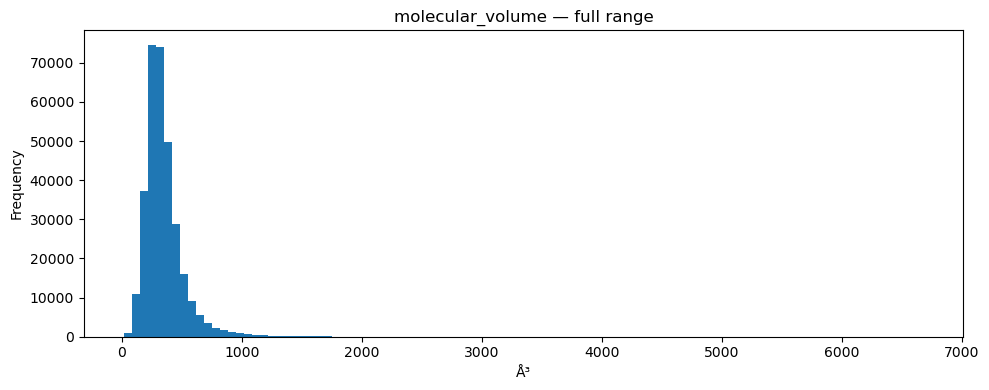

In [12]:
col = 'molecular_volume'
s = df[col].dropna()

print(s.describe().round(3).to_string())
print(f"\nMissing: {df[col].isna().sum():,} ({df[col].isna().mean()*100:.1f}%)")

idx_max = s.idxmax()
row_max = df.loc[idx_max]
print(f"\nLargest molecule:")
print(f"  identifier       : {row_max['identifier']}")
print(f"  molecular_volume : {row_max['molecular_volume']:.1f} Å³")
print(f"  molecular_weight : {row_max['molecular_weight']:.1f} g/mol")

s.plot.hist(bins=100, figsize=(10, 4))
plt.title('molecular_volume — full range')
plt.xlabel('Å³')
plt.tight_layout()
plt.show()

0.5th  percentile : 87.915 Å³
99.5th percentile : 1223.762 Å³
Values outside    : 3,198 (1.00%)

⚠ Note: min = 14.1 Å³ — negative values may indicate data errors (to investigate)

Histogram peak    : 298 Å³


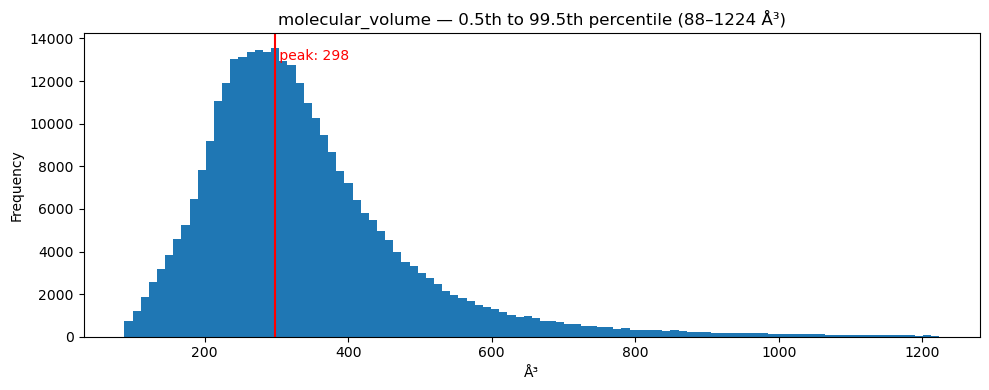

In [13]:
col = 'molecular_volume'
s = df[col].dropna()

p0_5 = s.quantile(0.005)
p99_5 = s.quantile(0.995)
print(f"0.5th  percentile : {p0_5:.3f} Å³")
print(f"99.5th percentile : {p99_5:.3f} Å³")
print(f"Values outside    : {((s < p0_5) | (s > p99_5)).sum():,} ({((s < p0_5) | (s > p99_5)).mean()*100:.2f}%)")
print(f"\n⚠ Note: min = {s.min():.1f} Å³ — negative values may indicate data errors (to investigate)")

s_zoom = s[(s >= p0_5) & (s <= p99_5)]
counts, edges = np.histogram(s_zoom, bins=100)
peak = (edges[counts.argmax()] + edges[counts.argmax() + 1]) / 2
print(f"\nHistogram peak    : {peak:.0f} Å³")

fig, ax = plt.subplots(figsize=(10, 4))
s_zoom.plot.hist(bins=100, ax=ax)
ax.axvline(peak, color='red', linewidth=1.5)
ax.text(peak, ax.get_ylim()[1] * 0.95, f' peak: {peak:.0f}', color='red', va='top')
ax.set_title(f'molecular_volume — 0.5th to 99.5th percentile ({p0_5:.0f}–{p99_5:.0f} Å³)')
ax.set_xlabel('Å³')
plt.tight_layout()
plt.show()

### Crystallographic properties

#### `z_prime`

count    339179.000
mean          0.948
std           0.165
min           0.000
25%           1.000
50%           1.000
75%           1.000
max           8.000


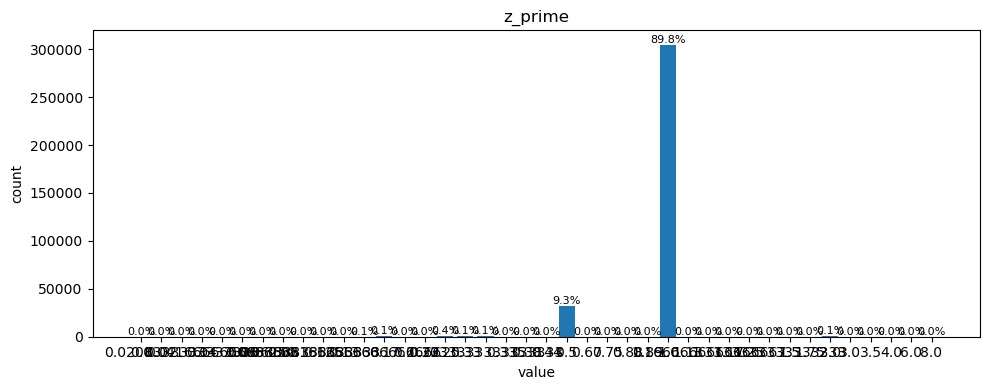

In [14]:
col = 'z_prime'
vc = df[col].value_counts().sort_index()

print(df[col].describe().round(3).to_string())

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(vc.index.astype(str), vc.values)
ax.set_title(col)
ax.set_xlabel('value')
ax.set_ylabel('count')
for bar, val in zip(ax.patches, vc.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f'{val/len(df)*100:.1f}%', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

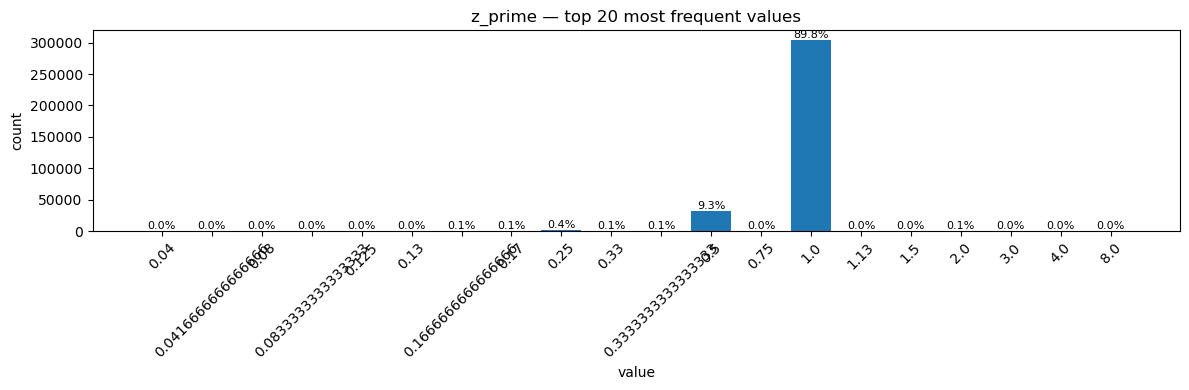

In [15]:
col = 'z_prime'
top20 = df[col].value_counts().nlargest(20).sort_index()

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(top20.index.astype(str), top20.values)
ax.set_title(f'{col} — top 20 most frequent values')
ax.set_xlabel('value')
ax.set_ylabel('count')
ax.tick_params(axis='x', rotation=45)
for bar, val in zip(ax.patches, top20.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f'{val/len(df)*100:.1f}%', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

#### `z_value`

count    339179.000
mean          3.899
std           2.111
min           0.400
25%           2.000
50%           4.000
75%           4.000
max          96.000

Unique values: 24


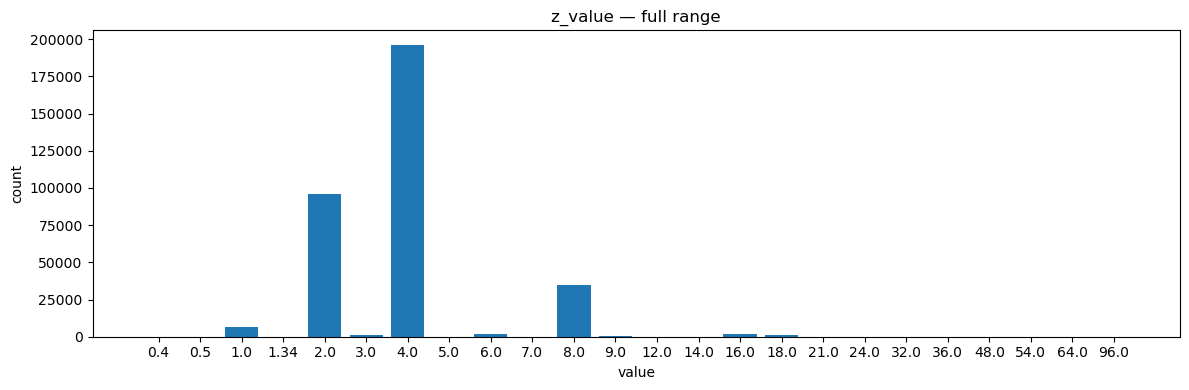

In [16]:
col = 'z_value'
vc = df[col].value_counts().sort_index()

print(df[col].describe().round(3).to_string())
print(f"\nUnique values: {df[col].nunique()}")

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(vc.index.astype(str), vc.values)
ax.set_title(f'{col} — full range')
ax.set_xlabel('value')
ax.set_ylabel('count')
plt.tight_layout()
plt.show()

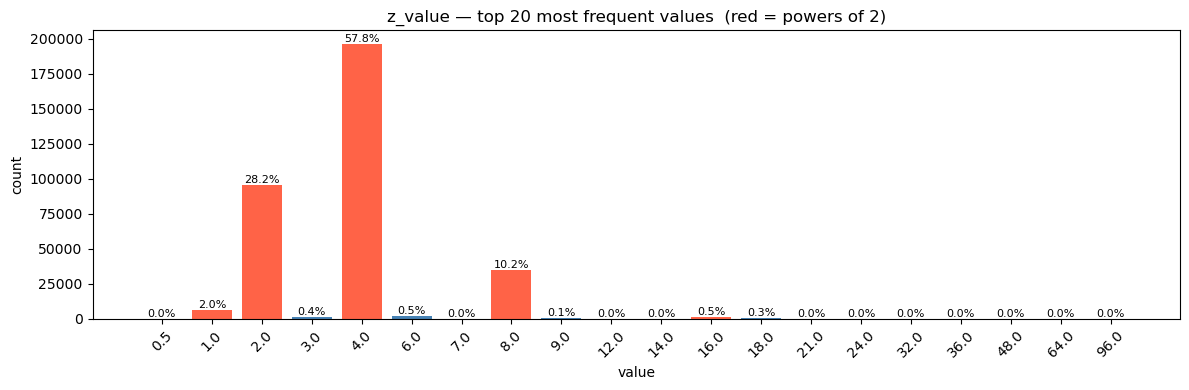

In [17]:
col = 'z_value'
top20 = df[col].value_counts().nlargest(20).sort_index()

powers_of_2 = {2**i for i in range(0, 10) if 2**i <= 512}
colors = ['tomato' if v in powers_of_2 else 'steelblue' for v in top20.index]

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(top20.index.astype(str), top20.values, color=colors)
ax.set_title(f'{col} — top 20 most frequent values  (red = powers of 2)')
ax.set_xlabel('value')
ax.set_ylabel('count')
ax.tick_params(axis='x', rotation=45)
for bar, val in zip(ax.patches, top20.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f'{val/len(df)*100:.1f}%', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

Values >= 20 : 60 (0.02% of total)


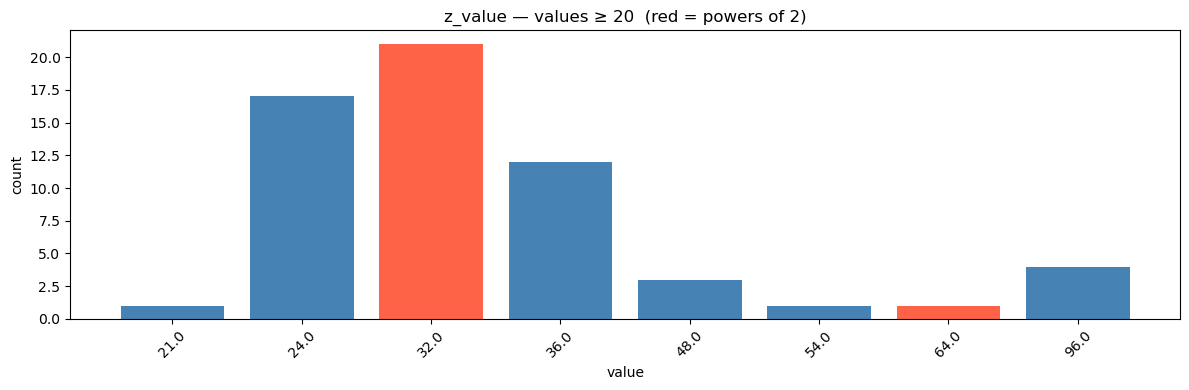

In [18]:
col = 'z_value'
tail = df[col].value_counts()
tail = tail[tail.index >= 20].sort_index()

print(f"Values >= 20 : {tail.sum():,} ({tail.sum()/len(df)*100:.2f}% of total)")

powers_of_2 = {2**i for i in range(0, 10) if 2**i <= 512}
colors = ['tomato' if v in powers_of_2 else 'steelblue' for v in tail.index]

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(tail.index.astype(str), tail.values, color=colors)
ax.set_title(f'{col} — values ≥ 20  (red = powers of 2)')
ax.set_xlabel('value')
ax.set_ylabel('count')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

#### `cell_length_a`

count    339179.000
mean         11.260
std           5.911
min           2.683
25%           7.630
50%           9.701
75%          12.924
max         144.310

Missing: 0 (0.0%)


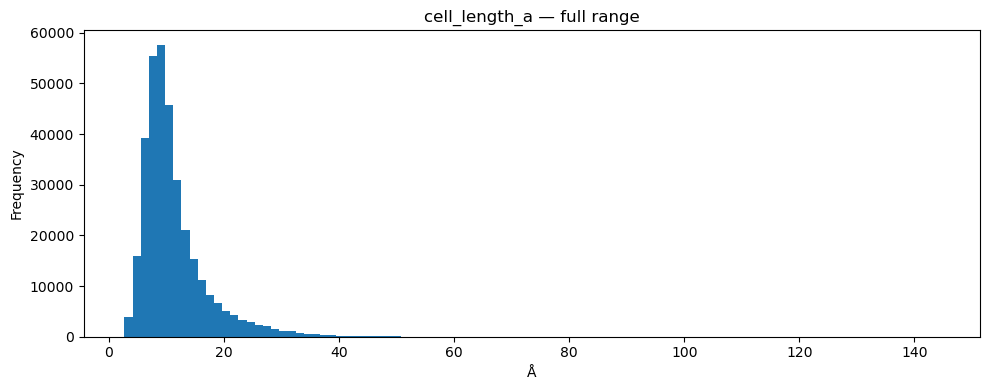

In [19]:
col = 'cell_length_a'
s = df[col].dropna()

print(s.describe().round(3).to_string())
print(f"\nMissing: {df[col].isna().sum():,} ({df[col].isna().mean()*100:.1f}%)")

s.plot.hist(bins=100, figsize=(10, 4))
plt.title(f'{col} — full range')
plt.xlabel('Å')
plt.tight_layout()
plt.show()

99th  percentile : 33.599 Å
Values above p99 : 3,392 (1.00%)

Histogram peak   : 8.09 Å


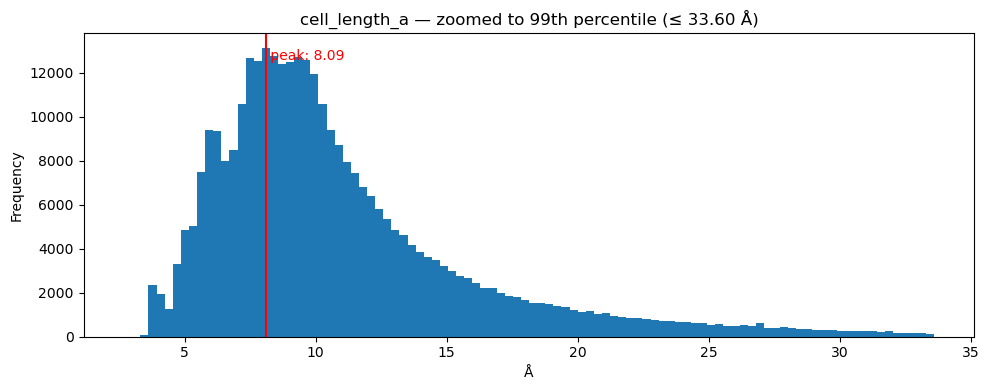

In [20]:
col = 'cell_length_a'
s = df[col].dropna()

p99 = s.quantile(0.99)
print(f"99th  percentile : {p99:.3f} Å")
print(f"Values above p99 : {(s > p99).sum():,} ({(s > p99).mean()*100:.2f}%)")

s_zoom = s[s <= p99]
counts, edges = np.histogram(s_zoom, bins=100)
peak = (edges[counts.argmax()] + edges[counts.argmax() + 1]) / 2
print(f"\nHistogram peak   : {peak:.2f} Å")

fig, ax = plt.subplots(figsize=(10, 4))
s_zoom.plot.hist(bins=100, ax=ax)
ax.axvline(peak, color='red', linewidth=1.5)
ax.text(peak, ax.get_ylim()[1] * 0.95, f' peak: {peak:.2f}', color='red', va='top')
ax.set_title(f'{col} — zoomed to 99th percentile (≤ {p99:.2f} Å)')
ax.set_xlabel('Å')
plt.tight_layout()
plt.show()

#### `cell_length_b`

count    339179.000
mean         11.978
std           5.609
min           2.683
25%           8.438
50%          10.715
75%          14.009
max         135.290

Missing: 0 (0.0%)


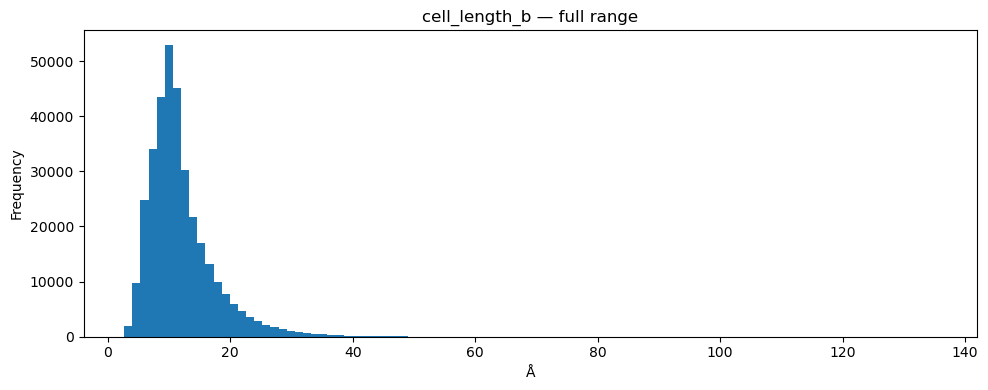

In [21]:
col = 'cell_length_b'
s = df[col].dropna()

print(s.describe().round(3).to_string())
print(f"\nMissing: {df[col].isna().sum():,} ({df[col].isna().mean()*100:.1f}%)")

s.plot.hist(bins=100, figsize=(10, 4))
plt.title(f'{col} — full range')
plt.xlabel('Å')
plt.tight_layout()
plt.show()

99th  percentile : 31.871 Å
Values above p99 : 3,392 (1.00%)

Histogram peak   : 10.13 Å


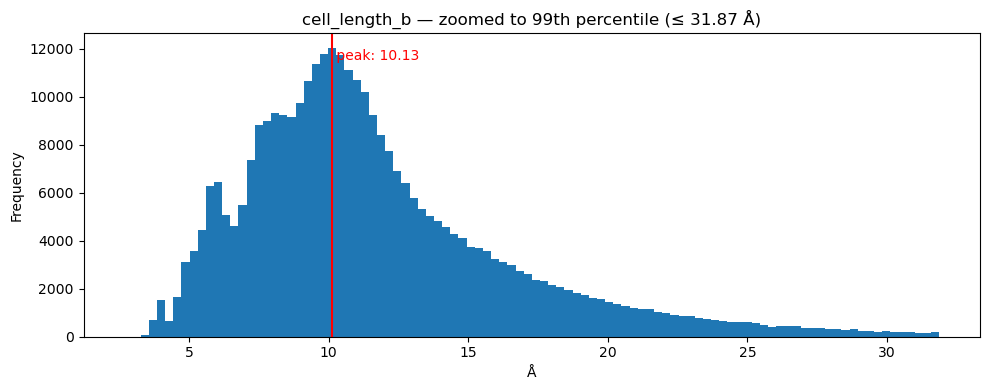

In [22]:
col = 'cell_length_b'
s = df[col].dropna()

p99 = s.quantile(0.99)
print(f"99th  percentile : {p99:.3f} Å")
print(f"Values above p99 : {(s > p99).sum():,} ({(s > p99).mean()*100:.2f}%)")

s_zoom = s[s <= p99]
counts, edges = np.histogram(s_zoom, bins=100)
peak = (edges[counts.argmax()] + edges[counts.argmax() + 1]) / 2
print(f"\nHistogram peak   : {peak:.2f} Å")

fig, ax = plt.subplots(figsize=(10, 4))
s_zoom.plot.hist(bins=100, ax=ax)
ax.axvline(peak, color='red', linewidth=1.5)
ax.text(peak, ax.get_ylim()[1] * 0.95, f' peak: {peak:.2f}', color='red', va='top')
ax.set_title(f'{col} — zoomed to 99th percentile (≤ {p99:.2f} Å)')
ax.set_xlabel('Å')
plt.tight_layout()
plt.show()

#### `cell_length_c`

count    339179.000
mean         15.545
std           6.727
min           2.962
25%          11.029
50%          14.200
75%          18.743
max         137.910

Missing: 0 (0.0%)


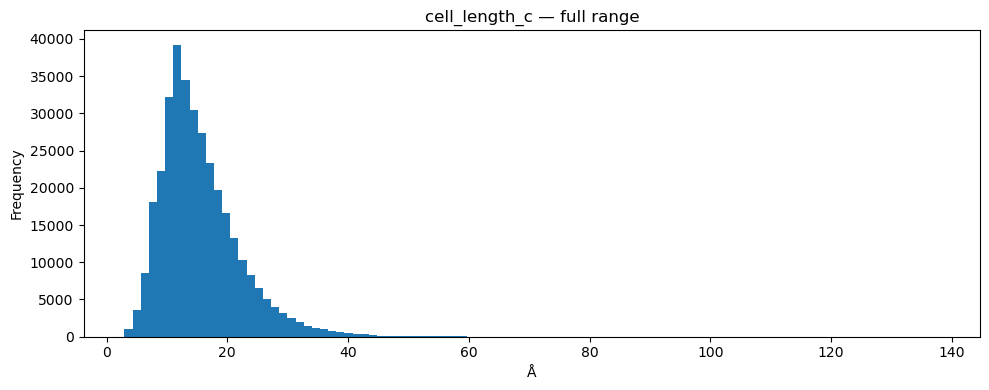

In [23]:
col = 'cell_length_c'
s = df[col].dropna()

print(s.describe().round(3).to_string())
print(f"\nMissing: {df[col].isna().sum():,} ({df[col].isna().mean()*100:.1f}%)")

s.plot.hist(bins=100, figsize=(10, 4))
plt.title(f'{col} — full range')
plt.xlabel('Å')
plt.tight_layout()
plt.show()

99th  percentile : 37.568 Å
Values above p99 : 3,392 (1.00%)

Histogram peak   : 11.79 Å


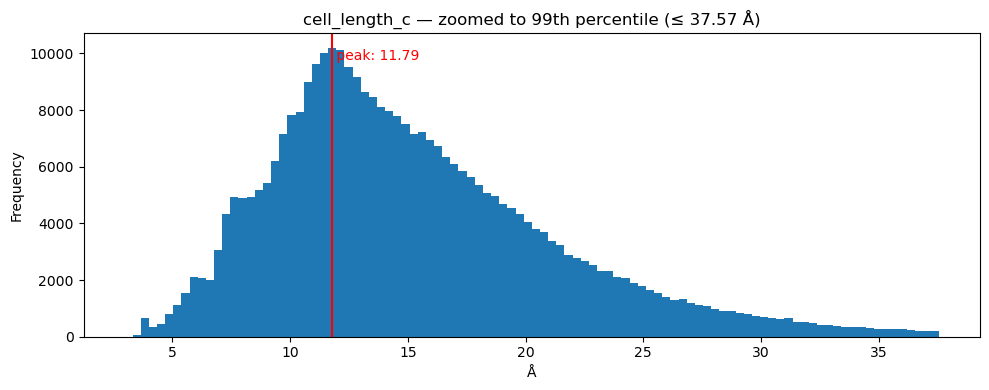

In [24]:
col = 'cell_length_c'
s = df[col].dropna()

p99 = s.quantile(0.99)
print(f"99th  percentile : {p99:.3f} Å")
print(f"Values above p99 : {(s > p99).sum():,} ({(s > p99).mean()*100:.2f}%)")

s_zoom = s[s <= p99]
counts, edges = np.histogram(s_zoom, bins=100)
peak = (edges[counts.argmax()] + edges[counts.argmax() + 1]) / 2
print(f"\nHistogram peak   : {peak:.2f} Å")

fig, ax = plt.subplots(figsize=(10, 4))
s_zoom.plot.hist(bins=100, ax=ax)
ax.axvline(peak, color='red', linewidth=1.5)
ax.text(peak, ax.get_ylim()[1] * 0.95, f' peak: {peak:.2f}', color='red', va='top')
ax.set_title(f'{col} — zoomed to 99th percentile (≤ {p99:.2f} Å)')
ax.set_xlabel('Å')
plt.tight_layout()
plt.show()

#### `cell_angle_alpha`

count    339179.000
mean         89.897
std           5.956
min          44.390
25%          90.000
50%          90.000
75%          90.000
max         137.500
  Near 90° (±0.5°) : 278,971 (82.2%)


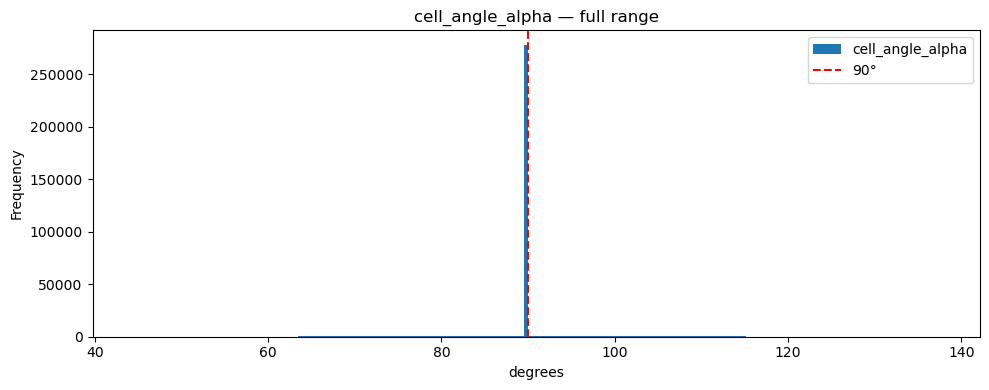

In [25]:
NOTABLE_ANGLES = {90: 'red'}
TOLERANCE = 0.5

col = 'cell_angle_alpha'
s = df[col].dropna()

print(s.describe().round(3).to_string())
for angle, color in NOTABLE_ANGLES.items():
    n = ((s >= angle - TOLERANCE) & (s <= angle + TOLERANCE)).sum()
    print(f"  Near {angle}° (±{TOLERANCE}°) : {n:,} ({n/len(s)*100:.1f}%)")

fig, ax = plt.subplots(figsize=(10, 4))
s.plot.hist(bins=200, ax=ax)
for angle, color in NOTABLE_ANGLES.items():
    ax.axvline(angle, color=color, linewidth=1.5, linestyle='--', label=f'{angle}°')
ax.set_title(f'{col} — full range')
ax.set_xlabel('degrees')
ax.legend()
plt.tight_layout()
plt.show()

Values outside 90° (±0.5°) : 60,208 (17.8%)


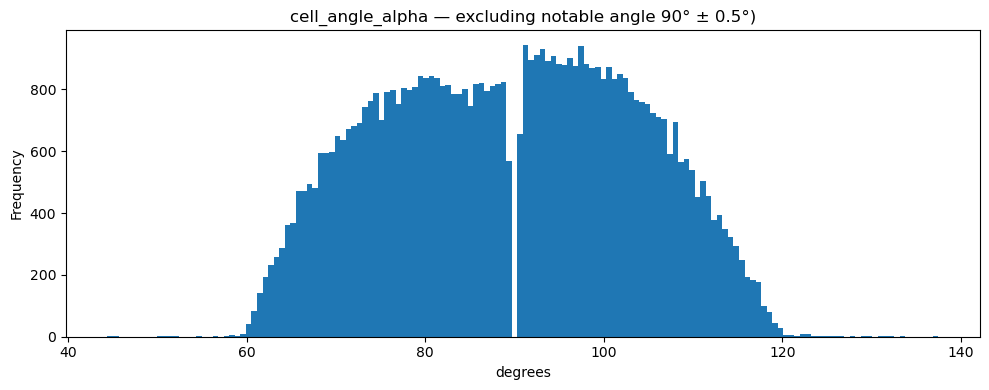

In [26]:
col = 'cell_angle_alpha'
s = df[col].dropna()

mask_notable = sum((s >= a - TOLERANCE) & (s <= a + TOLERANCE) for a in NOTABLE_ANGLES)
s_other = s[mask_notable == 0]
print(f"Values outside 90° (±{TOLERANCE}°) : {len(s_other):,} ({len(s_other)/len(s)*100:.1f}%)")

fig, ax = plt.subplots(figsize=(10, 4))
s_other.plot.hist(bins=150, ax=ax)
ax.set_title(f'{col} — excluding notable angle 90° ± {TOLERANCE}°)')
ax.set_xlabel('degrees')
plt.tight_layout()
plt.show()

#### `cell_angle_beta`

count    339179.000
mean         96.187
std           9.790
min          18.399
25%          90.000
50%          94.020
75%         102.164
max         169.263
  Near 90° (±0.5°) : 98,554 (29.1%)


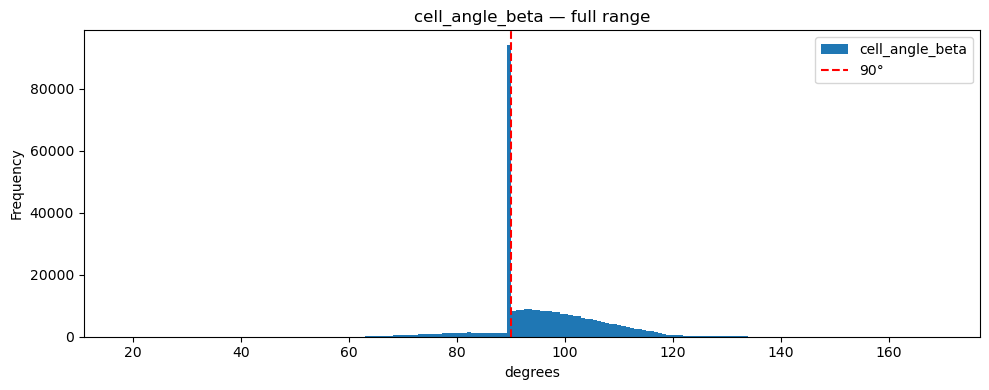

In [27]:
col = 'cell_angle_beta'
s = df[col].dropna()

print(s.describe().round(3).to_string())
for angle, color in NOTABLE_ANGLES.items():
    n = ((s >= angle - TOLERANCE) & (s <= angle + TOLERANCE)).sum()
    print(f"  Near {angle}° (±{TOLERANCE}°) : {n:,} ({n/len(s)*100:.1f}%)")

fig, ax = plt.subplots(figsize=(10, 4))
s.plot.hist(bins=200, ax=ax)
for angle, color in NOTABLE_ANGLES.items():
    ax.axvline(angle, color=color, linewidth=1.5, linestyle='--', label=f'{angle}°')
ax.set_title(f'{col} — full range')
ax.set_xlabel('degrees')
ax.legend()
plt.tight_layout()
plt.show()

Values outside 90° (±0.5°) : 240,625 (70.9%)


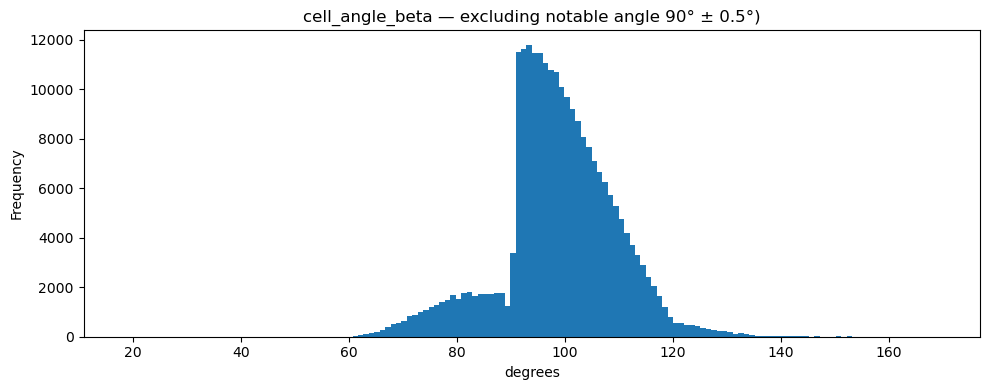

In [28]:
col = 'cell_angle_beta'
s = df[col].dropna()

mask_notable = sum((s >= a - TOLERANCE) & (s <= a + TOLERANCE) for a in NOTABLE_ANGLES)
s_other = s[mask_notable == 0]
print(f"Values outside 90° (±{TOLERANCE}°) : {len(s_other):,} ({len(s_other)/len(s)*100:.1f}%)")

fig, ax = plt.subplots(figsize=(10, 4))
s_other.plot.hist(bins=150, ax=ax)
ax.set_title(f'{col} — excluding notable angle 90° ± {TOLERANCE}°)')
ax.set_xlabel('degrees')
plt.tight_layout()
plt.show()

#### `cell_angle_gamma`

count    339179.000
mean         90.259
std           7.118
min          49.040
25%          90.000
50%          90.000
75%          90.000
max         155.220
  Near 90° (±0.5°) : 273,824 (80.7%)
  Near 120° (±0.5°) : 4,631 (1.4% of total, 7.1% of non-90°)


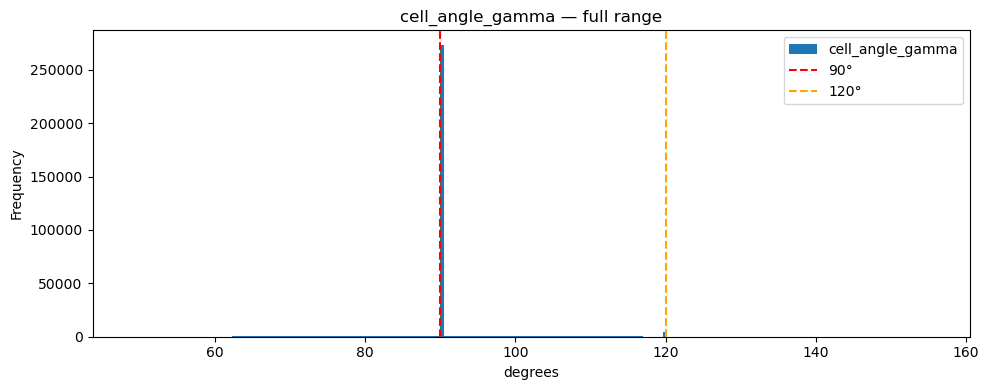

In [29]:
col = 'cell_angle_gamma'
s = df[col].dropna()

print(s.describe().round(3).to_string())
for angle, color in NOTABLE_ANGLES.items():
    n = ((s >= angle - TOLERANCE) & (s <= angle + TOLERANCE)).sum()
    print(f"  Near {angle}° (±{TOLERANCE}°) : {n:,} ({n/len(s)*100:.1f}%)")
n_120 = ((s >= 120 - TOLERANCE) & (s <= 120 + TOLERANCE)).sum()
n_non90 = ((s < 90 - TOLERANCE) | (s > 90 + TOLERANCE)).sum()
print(f"  Near 120° (±{TOLERANCE}°) : {n_120:,} ({n_120/len(s)*100:.1f}% of total, {n_120/n_non90*100:.1f}% of non-90°)")

fig, ax = plt.subplots(figsize=(10, 4))
s.plot.hist(bins=200, ax=ax)
for angle, color in NOTABLE_ANGLES.items():
    ax.axvline(angle, color=color, linewidth=1.5, linestyle='--', label=f'{angle}°')
ax.axvline(120, color='orange', linewidth=1.5, linestyle='--', label='120°')
ax.set_title(f'{col} — full range')
ax.set_xlabel('degrees')
ax.legend()
plt.tight_layout()
plt.show()

Values outside 90° (±0.5°) : 65,355 (19.3%)


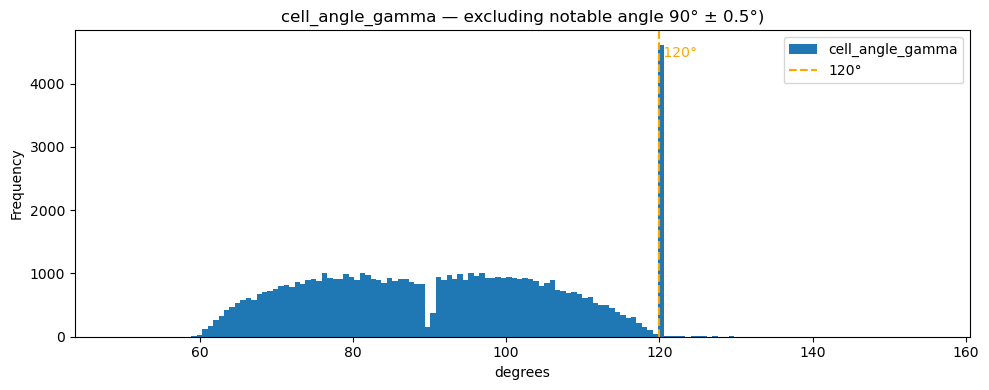

In [30]:
col = 'cell_angle_gamma'
s = df[col].dropna()

mask_notable = sum((s >= a - TOLERANCE) & (s <= a + TOLERANCE) for a in NOTABLE_ANGLES)
s_other = s[mask_notable == 0]
print(f"Values outside 90° (±{TOLERANCE}°) : {len(s_other):,} ({len(s_other)/len(s)*100:.1f}%)")

fig, ax = plt.subplots(figsize=(10, 4))
s_other.plot.hist(bins=150, ax=ax)
ax.axvline(120, color='orange', linewidth=1.5, linestyle='--', label='120°')
ax.text(120, ax.get_ylim()[1] * 0.95, ' 120°', color='orange', va='top')
ax.set_title(f'{col} — excluding notable angle 90° ± {TOLERANCE}°)')
ax.set_xlabel('degrees')
ax.legend()
plt.tight_layout()
plt.show()

#### `cell_volume`

count    339179.000
mean       1880.617
std        1808.369
min          38.927
25%        1039.893
50%        1529.257
75%        2214.268
max      194336.954

Missing: 0 (0.0%)


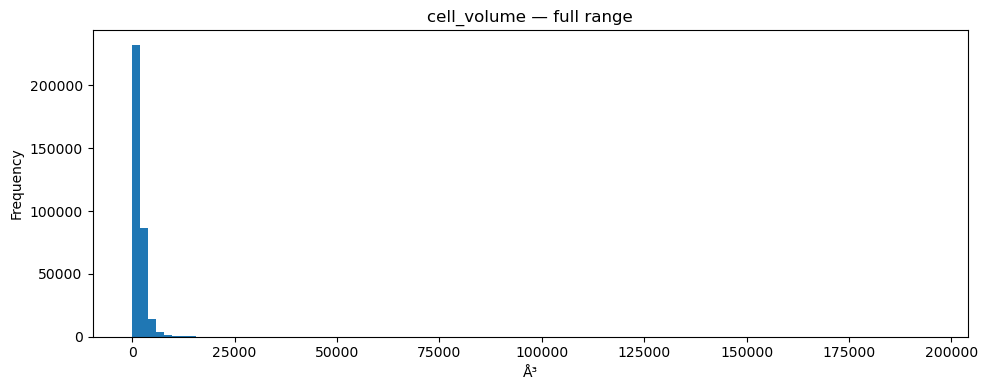

In [31]:
col = 'cell_volume'
s = df[col].dropna()

print(s.describe().round(3).to_string())
print(f"\nMissing: {df[col].isna().sum():,} ({df[col].isna().mean()*100:.1f}%)")

s.plot.hist(bins=100, figsize=(10, 4))
plt.title(f'{col} — full range')
plt.xlabel('Å³')
plt.tight_layout()
plt.show()

99th  percentile : 7423.9 Å³
Values above p99 : 3,392 (1.00%)

Histogram peak   : 1331 Å³


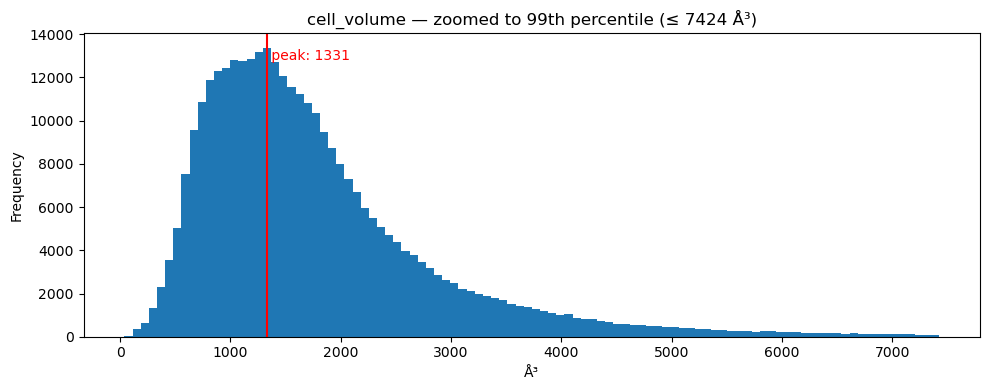

In [32]:
col = 'cell_volume'
s = df[col].dropna()

p99 = s.quantile(0.99)
print(f"99th  percentile : {p99:.1f} Å³")
print(f"Values above p99 : {(s > p99).sum():,} ({(s > p99).mean()*100:.2f}%)")

s_zoom = s[s <= p99]
counts, edges = np.histogram(s_zoom, bins=100)
peak = (edges[counts.argmax()] + edges[counts.argmax() + 1]) / 2
print(f"\nHistogram peak   : {peak:.0f} Å³")

fig, ax = plt.subplots(figsize=(10, 4))
s_zoom.plot.hist(bins=100, ax=ax)
ax.axvline(peak, color='red', linewidth=1.5)
ax.text(peak, ax.get_ylim()[1] * 0.95, f' peak: {peak:.0f}', color='red', va='top')
ax.set_title(f'{col} — zoomed to 99th percentile (≤ {p99:.0f} Å³)')
ax.set_xlabel('Å³')
plt.tight_layout()
plt.show()

#### `spacegroup_number`

In [33]:
col = 'spacegroup_number'
print(f"Unique space groups : {df[col].nunique()} / 230")
print(f"Missing             : {df[col].isna().sum():,} ({df[col].isna().mean()*100:.1f}%)\n")

s = df[col].dropna()
out_of_range = s[(s < 1) | (s > 230)]
non_integer  = s[s != s.apply(int)]
print(f"Values out of range (< 1 or > 230) : {len(out_of_range):,}")
print(f"Non-integer values                 : {len(non_integer):,}")
if len(non_integer) > 0:
    print(f"  Examples: {sorted(non_integer.unique())[:10]}")
if len(out_of_range) > 0:
    print(f"  Examples: {sorted(out_of_range.unique())[:10]}")

valid = s[(s >= 1) & (s <= 230)]
print(f"\nUnique space groups (valid 1–230 only) : {valid.nunique()} / 230")

print("\nTop 10:")
vc = df[col].value_counts()
for sg, count in vc.head(10).items():
    symbol = df.loc[df[col] == sg, 'spacegroup_symbol'].iloc[0]
    print(f"  #{int(sg):<4} {symbol:<12} {count:>9,} ({count/len(df)*100:.1f}%)")

Unique space groups : 185 / 230
Missing             : 1 (0.0%)

Values out of range (< 1 or > 230) : 0
Non-integer values                 : 0

Unique space groups (valid 1–230 only) : 185 / 230

Top 10:
  #14   P21/n          129,486 (38.2%)
  #2    P-1             59,933 (17.7%)
  #19   P212121         47,179 (13.9%)
  #4    P21             26,153 (7.7%)
  #15   C2/c            21,104 (6.2%)
  #61   Pbca            15,240 (4.5%)
  #33   Pna21            5,396 (1.6%)
  #5    C2               3,348 (1.0%)
  #9    Cc               3,061 (0.9%)
  #29   Pca21            2,807 (0.8%)


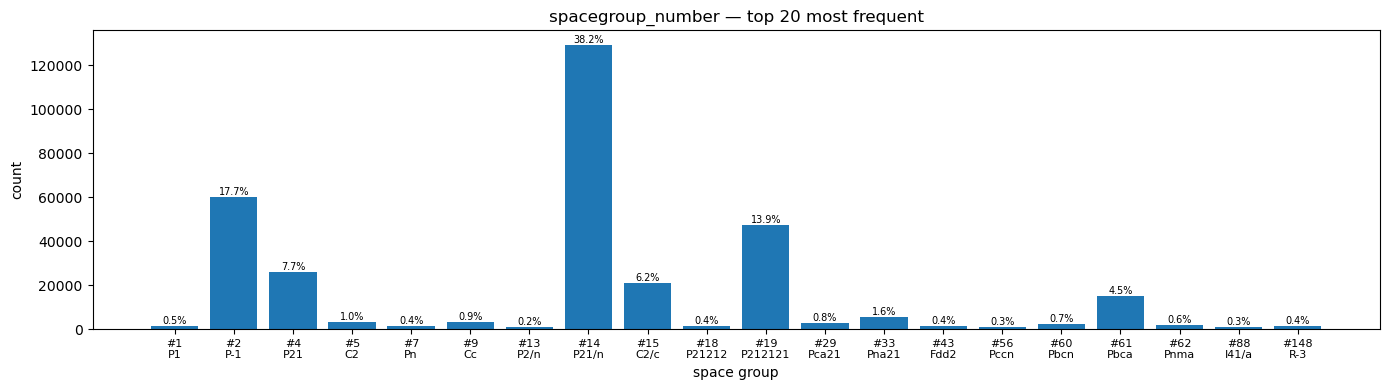

In [34]:
col = 'spacegroup_number'
top20 = df[col].value_counts().nlargest(20).sort_index()
labels = [f"#{int(sg)}\n{df.loc[df[col]==sg, 'spacegroup_symbol'].iloc[0]}" for sg in top20.index]

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(labels, top20.values)
ax.set_title(f'{col} — top 20 most frequent')
ax.set_xlabel('space group')
ax.set_ylabel('count')
ax.tick_params(axis='x', labelsize=8)
for bar, val in zip(ax.patches, top20.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f'{val/len(df)*100:.1f}%', ha='center', va='bottom', fontsize=7)
plt.tight_layout()
plt.show()

#### `spacegroup_setting`

Unique values : 16
Missing       : 1 (0.0%)

  Setting 1      279,948 (82.5%)
  Setting 2       51,921 (15.3%)
  Setting 3        5,958 (1.8%)
  Setting 4          240 (0.1%)
  Setting 5          271 (0.1%)
  Setting 6          502 (0.1%)
  Setting 7            7 (0.0%)
  Setting 8            3 (0.0%)
  Setting 9           10 (0.0%)
  Setting 10          97 (0.0%)
  Setting 11          18 (0.0%)
  Setting 12         156 (0.0%)
  Setting 13          39 (0.0%)
  Setting 15           5 (0.0%)
  Setting 19           2 (0.0%)
  Setting 21           1 (0.0%)


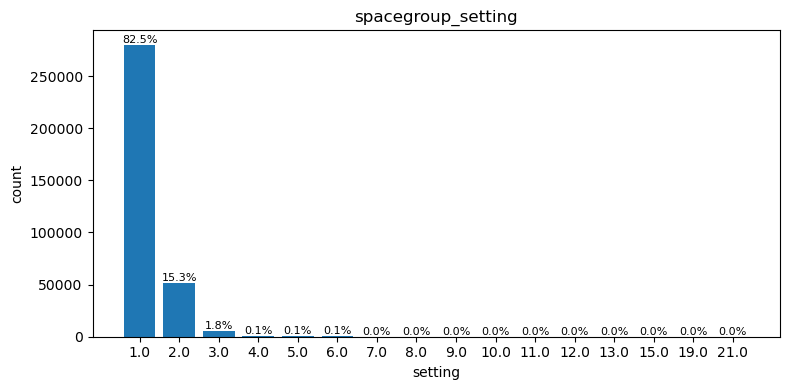

In [35]:
col = 'spacegroup_setting'
vc = df[col].value_counts().sort_index()
print(f"Unique values : {df[col].nunique()}")
print(f"Missing       : {df[col].isna().sum():,} ({df[col].isna().mean()*100:.1f}%)\n")
for val, count in vc.items():
    print(f"  Setting {int(val):<4} {count:>9,} ({count/len(df)*100:.1f}%)")

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(vc.index.astype(str), vc.values)
ax.set_title(col)
ax.set_xlabel('setting')
ax.set_ylabel('count')
for bar, val in zip(ax.patches, vc.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f'{val/len(df)*100:.1f}%', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

#### `r_factor`

count    338046.000
mean          5.125
std           2.245
min           0.026
25%           3.790
50%           4.640
75%           5.870
max          97.540

Missing: 1,133 (0.3%)


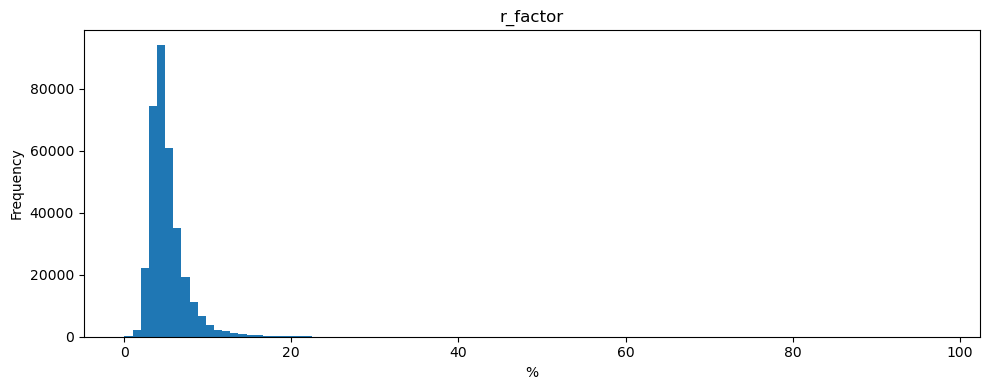

In [36]:
col = 'r_factor'
print(df[col].describe().round(3).to_string())
print(f"\nMissing: {df[col].isna().sum():,} ({df[col].isna().mean()*100:.1f}%)")

df[col].dropna().plot.hist(bins=100, figsize=(10, 4))
plt.title('r_factor')
plt.xlabel('%')
plt.tight_layout()
plt.show()

99th   percentile : 13.400 %
99.9th percentile : 21.900 %
Values above p99  : 3,365 (1.00%)

Histogram peak    : 4.239 %


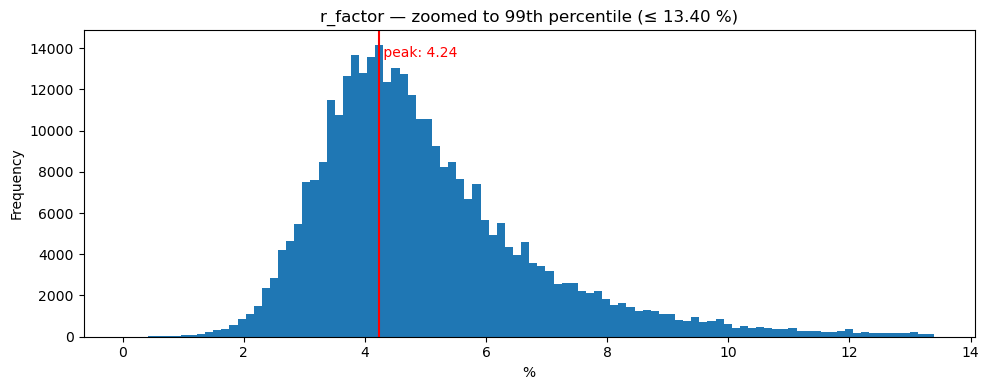

In [37]:
col = 'r_factor'
s = df[col].dropna()

p99 = s.quantile(0.99)
p999 = s.quantile(0.999)
print(f"99th   percentile : {p99:.3f} %")
print(f"99.9th percentile : {p999:.3f} %")
print(f"Values above p99  : {(s > p99).sum():,} ({(s > p99).mean()*100:.2f}%)")

s_zoom = s[s <= p99]
counts, edges = np.histogram(s_zoom, bins=100)
peak = (edges[counts.argmax()] + edges[counts.argmax() + 1]) / 2
print(f"\nHistogram peak    : {peak:.3f} %")

fig, ax = plt.subplots(figsize=(10, 4))
s_zoom.plot.hist(bins=100, ax=ax)
ax.axvline(peak, color='red', linewidth=1.5)
ax.text(peak, ax.get_ylim()[1] * 0.95, f' peak: {peak:.2f}', color='red', va='top')
ax.set_title(f'r_factor — zoomed to 99th percentile (≤ {p99:.2f} %)')
ax.set_xlabel('%')
plt.tight_layout()
plt.show()

### `publication_years`

count    339177.0
mean       2011.0
std          12.0
min        1936.0
25%        2006.0
50%        2014.0
75%        2020.0
max        2026.0

Missing: 2 (0.0%)
Range  : 1936 – 2026


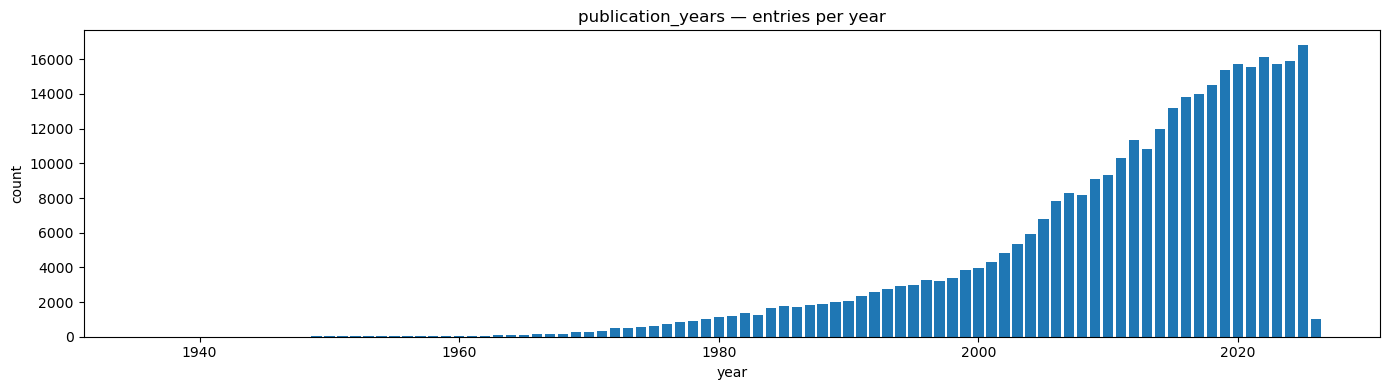

In [38]:
col = 'publication_years'
s = df[col].dropna()

print(s.describe().round(0).to_string())
print(f"\nMissing: {df[col].isna().sum():,} ({df[col].isna().mean()*100:.1f}%)")
print(f"Range  : {int(s.min())} – {int(s.max())}")

vc = s.astype(int).value_counts().sort_index()
fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(vc.index, vc.values, width=0.8)
ax.set_title('publication_years — entries per year')
ax.set_xlabel('year')
ax.set_ylabel('count')
plt.tight_layout()
plt.show()

1st percentile : 1974  — zooming from there


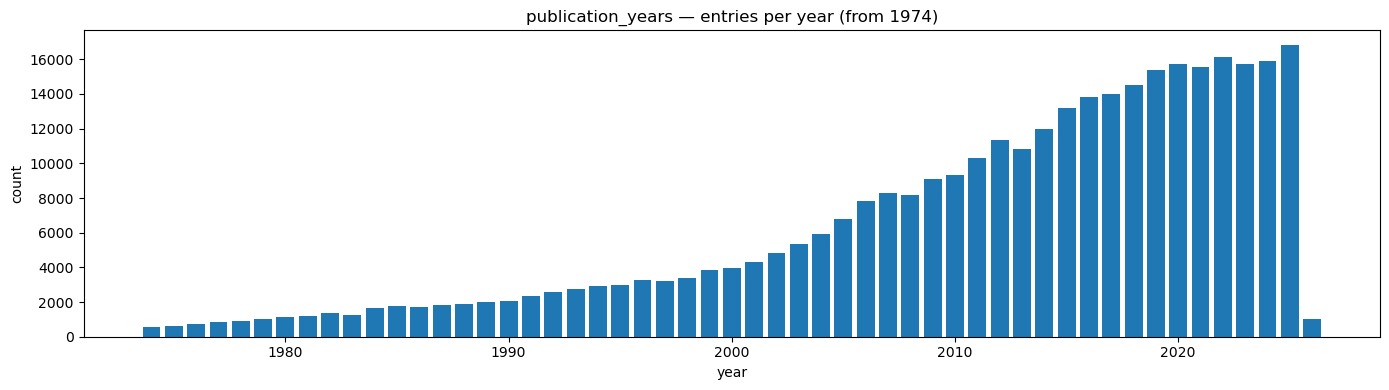

In [39]:
col = 'publication_years'
s = df[col].dropna()

p1 = int(s.quantile(0.01))
print(f"1st percentile : {p1}  — zooming from there")

vc = s.astype(int).value_counts().sort_index()
vc_zoom = vc[vc.index >= p1]

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(vc_zoom.index, vc_zoom.values, width=0.8)
ax.set_title(f'publication_years — entries per year (from {p1})')
ax.set_xlabel('year')
ax.set_ylabel('count')
plt.tight_layout()
plt.show()

### `deposition_date`

Missing : 0 (0.0%)
Range   : 1971 – 2026

count    339179.0
mean       2012.0
std          12.0
min        1971.0
25%        2006.0
50%        2015.0
75%        2020.0
max        2026.0


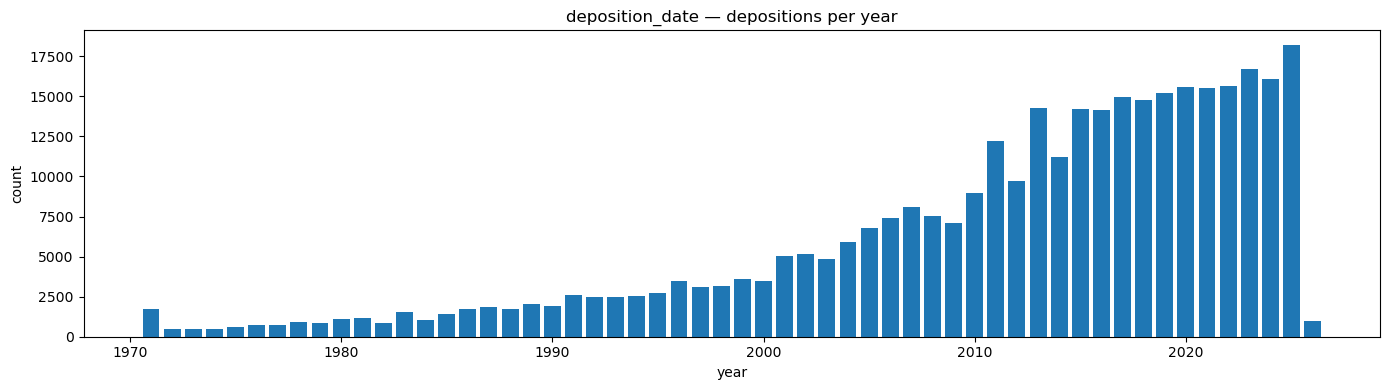

In [40]:
col = 'deposition_date'
s_year = pd.to_datetime(df[col], errors='coerce').dt.year.dropna()

print(f"Missing : {df[col].isna().sum():,} ({df[col].isna().mean()*100:.1f}%)")
print(f"Range   : {int(s_year.min())} – {int(s_year.max())}")
print(f"\n{s_year.describe().round(0).to_string()}")

vc = s_year.astype(int).value_counts().sort_index()
fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(vc.index, vc.values, width=0.8)
ax.set_title('deposition_date — depositions per year')
ax.set_xlabel('year')
ax.set_ylabel('count')
plt.tight_layout()
plt.show()

1st percentile : 1975  — zooming from there


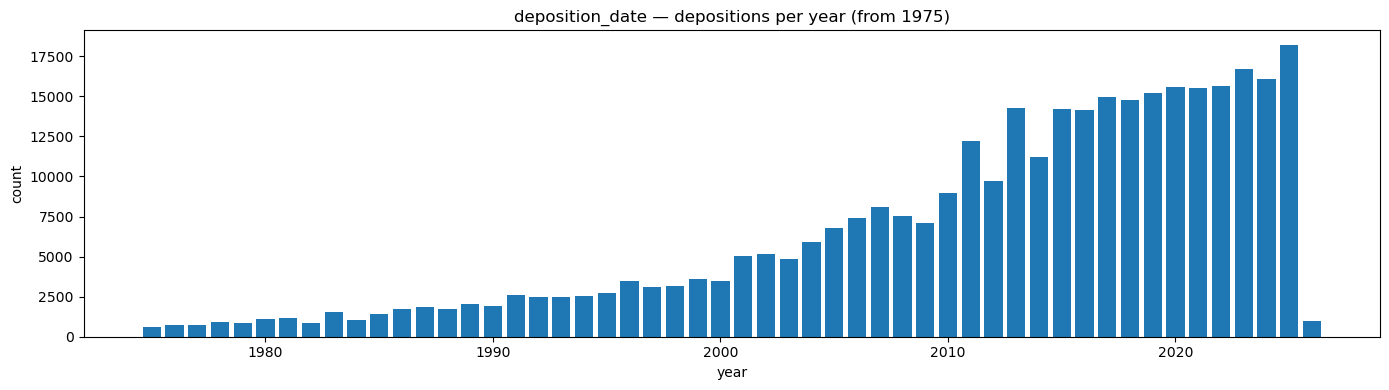

In [41]:
col = 'deposition_date'
s_year = pd.to_datetime(df[col], errors='coerce').dt.year.dropna()

p1 = int(s_year.quantile(0.01))
print(f"1st percentile : {p1}  — zooming from there")

vc = s_year.astype(int).value_counts().sort_index()
vc_zoom = vc[vc.index >= p1]

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(vc_zoom.index, vc_zoom.values, width=0.8)
ax.set_title(f'deposition_date — depositions per year (from {p1})')
ax.set_xlabel('year')
ax.set_ylabel('count')
plt.tight_layout()
plt.show()

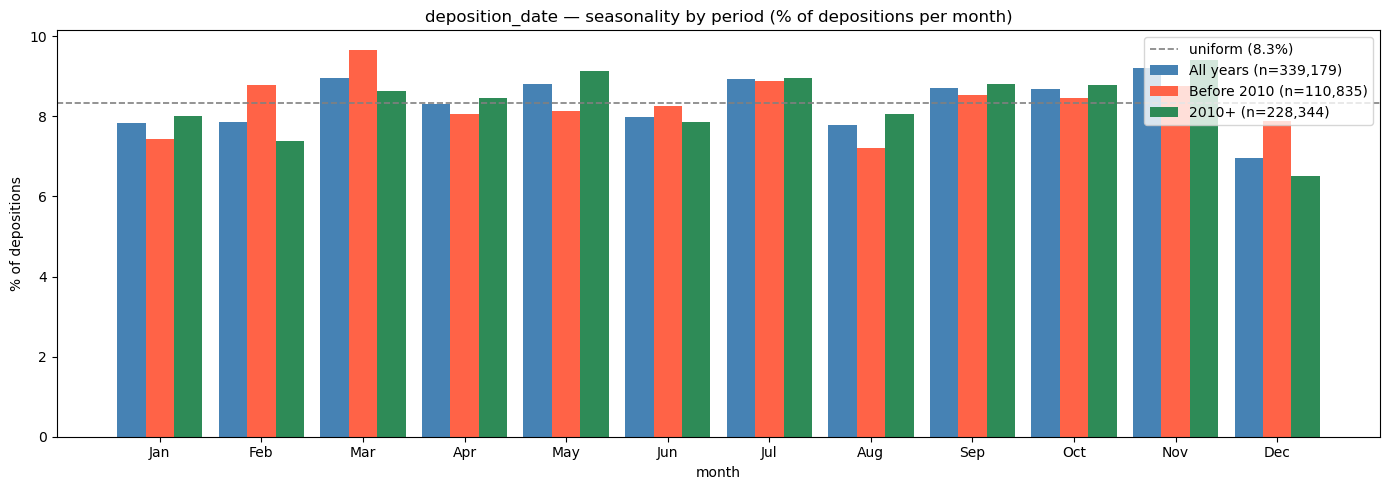

Before 2010 : 110,835 depositions
2010+       : 228,344 depositions


In [42]:
col = 'deposition_date'
s_date = pd.to_datetime(df[col], errors='coerce')

s_all    = s_date.dt.month.dropna().astype(int)
s_before = s_date[s_date.dt.year < 2010].dt.month.dropna().astype(int)
s_after  = s_date[s_date.dt.year >= 2010].dt.month.dropna().astype(int)

MONTH_LABELS = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

def monthly_pct(s):
    vc = s.value_counts().sort_index().reindex(range(1, 13), fill_value=0)
    return vc / vc.sum() * 100

pct_all    = monthly_pct(s_all)
pct_before = monthly_pct(s_before)
pct_after  = monthly_pct(s_after)

x = np.arange(1, 13)
width = 0.28

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x - width, pct_all.values,    width=width, label=f'All years (n={len(s_all):,})',       color='steelblue')
ax.bar(x,         pct_before.values, width=width, label=f'Before 2010 (n={len(s_before):,})', color='tomato')
ax.bar(x + width, pct_after.values,  width=width, label=f'2010+ (n={len(s_after):,})',        color='seagreen')
ax.axhline(100 / 12, color='gray', linewidth=1.2, linestyle='--', label='uniform (8.3%)')

ax.set_xticks(x)
ax.set_xticklabels(MONTH_LABELS)
ax.set_title('deposition_date — seasonality by period (% of depositions per month)')
ax.set_xlabel('month')
ax.set_ylabel('% of depositions')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Before 2010 : {len(s_before):,} depositions")
print(f"2010+       : {len(s_after):,} depositions")

### `deposition_date` vs `publication_years` — lag analysis

Entries with both dates : 339,177

Lag = publication_year − deposition_year:
count    339177.0
mean         -0.4
std           1.4
min         -83.0
25%          -1.0
50%           0.0
75%           0.0
max          17.0

  Negative (published before deposition) :   99,452 (29.3%)
  Zero     (same year)                   :  231,590 (68.3%)
  Positive (deposition before publication):    8,135 (2.4%)


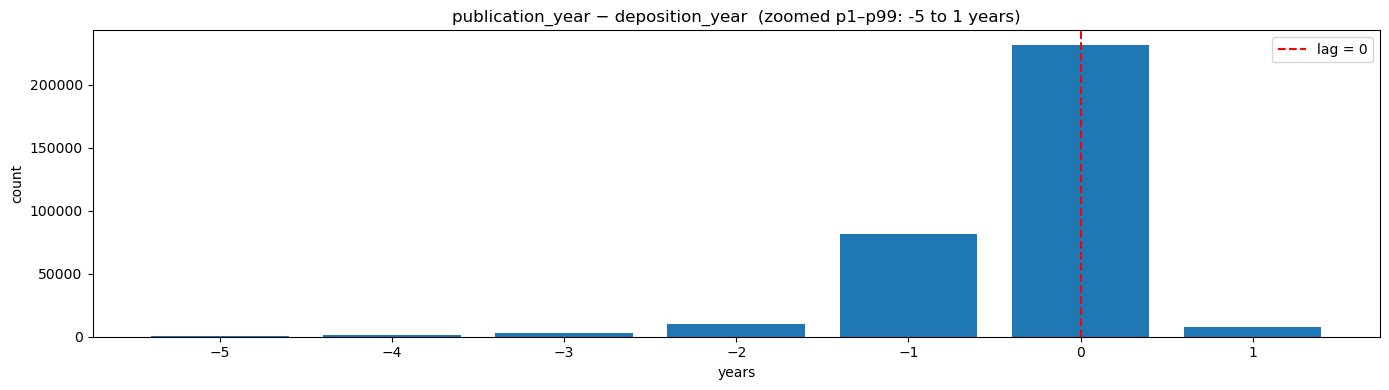

In [43]:
dep_year = pd.to_datetime(df['deposition_date'], errors='coerce').dt.year
pub_year = df['publication_years'].astype(str).str.split('|').str[0].replace('nan', None)
pub_year = pd.to_numeric(pub_year, errors='coerce')

comp = pd.DataFrame({'deposition_year': dep_year, 'publication_year': pub_year}).dropna()
comp['lag'] = (comp['publication_year'] - comp['deposition_year']).astype(int)

print(f"Entries with both dates : {len(comp):,}")
print(f"\nLag = publication_year − deposition_year:")
print(comp['lag'].describe().round(1).to_string())
print(f"\n  Negative (published before deposition) : {(comp['lag'] < 0).sum():>8,} ({(comp['lag'] < 0).mean()*100:.1f}%)")
print(f"  Zero     (same year)                   : {(comp['lag'] == 0).sum():>8,} ({(comp['lag'] == 0).mean()*100:.1f}%)")
print(f"  Positive (deposition before publication): {(comp['lag'] > 0).sum():>8,} ({(comp['lag'] > 0).mean()*100:.1f}%)")

p1  = int(comp['lag'].quantile(0.01))
p99 = int(comp['lag'].quantile(0.99))
vc_lag = comp['lag'].value_counts().sort_index()
vc_zoom = vc_lag[(vc_lag.index >= p1) & (vc_lag.index <= p99)]

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(vc_zoom.index, vc_zoom.values, width=0.8)
ax.axvline(0, color='red', linewidth=1.5, linestyle='--', label='lag = 0')
ax.set_title(f'publication_year − deposition_year  (zoomed p1–p99: {p1} to {p99} years)')
ax.set_xlabel('years')
ax.set_ylabel('count')
ax.legend()
plt.tight_layout()
plt.show()

## Categorical columns

### `radiation_source`

Unique values : 4

  X-ray                  197,570 (58.2%)
  Unknown                140,565 (41.4%)
  Neutron                    756 (0.2%)
  Electron                   288 (0.1%)


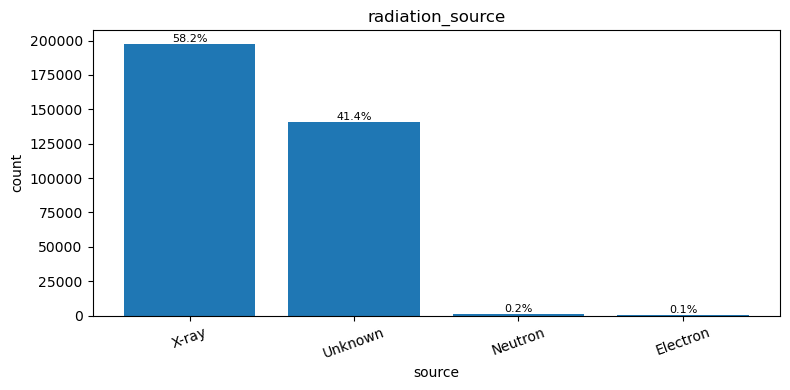

In [44]:
col = 'radiation_source'
vc = df[col].value_counts()
print(f"Unique values : {df[col].nunique()}\n")
for val, count in vc.items():
    print(f"  {val:<20} {count:>9,} ({count/len(df)*100:.1f}%)")

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(vc.index, vc.values)
ax.set_title(col)
ax.set_xlabel('source')
ax.set_ylabel('count')
ax.tick_params(axis='x', rotation=20)
for bar, val in zip(ax.patches, vc.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f'{val/len(df)*100:.1f}%', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

### `color`

Unique values : 983
Missing       : 50,221 (14.8%)

  colorless                   196,362 (57.9%)
  yellow                       34,760 (10.2%)
  orange                        8,213 (2.4%)
  white                         7,237 (2.1%)
  red                           7,080 (2.1%)
  light colorless               5,744 (1.7%)
  light yellow                  4,901 (1.4%)
  pale yellow                   4,704 (1.4%)
  brown                         2,447 (0.7%)
  black                         1,385 (0.4%)
  green                         1,368 (0.4%)
  dark red                        799 (0.2%)
  light brown                     674 (0.2%)
  purple                          635 (0.2%)
  blue                            633 (0.2%)
  light orange                    440 (0.1%)
  whiteish colorless              420 (0.1%)
  pink                            408 (0.1%)
  Colorless                       384 (0.1%)
  violet                          364 (0.1%)


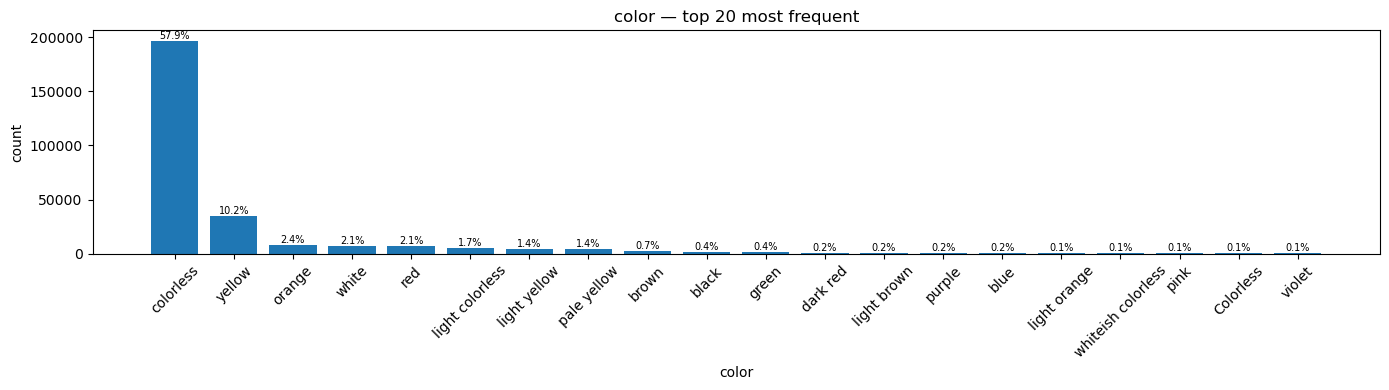

In [45]:
col = 'color'
print(f"Unique values : {df[col].nunique()}")
print(f"Missing       : {df[col].isna().sum():,} ({df[col].isna().mean()*100:.1f}%)\n")

top20 = df[col].value_counts().nlargest(20)
for val, count in top20.items():
    print(f"  {val:<25} {count:>9,} ({count/len(df)*100:.1f}%)")

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(top20.index, top20.values)
ax.set_title(f'{col} — top 20 most frequent')
ax.set_xlabel('color')
ax.set_ylabel('count')
ax.tick_params(axis='x', rotation=45)
for bar, val in zip(ax.patches, top20.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f'{val/len(df)*100:.1f}%', ha='center', va='bottom', fontsize=7)
plt.tight_layout()
plt.show()

### `solvent`

Unique values : 5992
Missing       : 271,703 (80.1%)

  ethanol                                 6,917 (2.0%)
  methanol                                4,544 (1.3%)
  ethyl acetate                           2,738 (0.8%)
  dichloromethane                         2,366 (0.7%)
  chloroform                              2,045 (0.6%)
  acetone                                 1,927 (0.6%)
  hexane                                  1,844 (0.5%)
  acetonitrile                            1,568 (0.5%)
  dichloromethane/hexane                  1,516 (0.4%)
  diethyl ether                           1,174 (0.3%)
  toluene                                 1,150 (0.3%)
  ethyl acetate/hexane                    1,076 (0.3%)
  hexane/ethyl acetate                      636 (0.2%)
  dichloromethane/methanol                  594 (0.2%)
  n-hexane                                  590 (0.2%)
  benzene                                   540 (0.2%)
  chloroform/hexane                         524 (0.2%)
  hexane/di

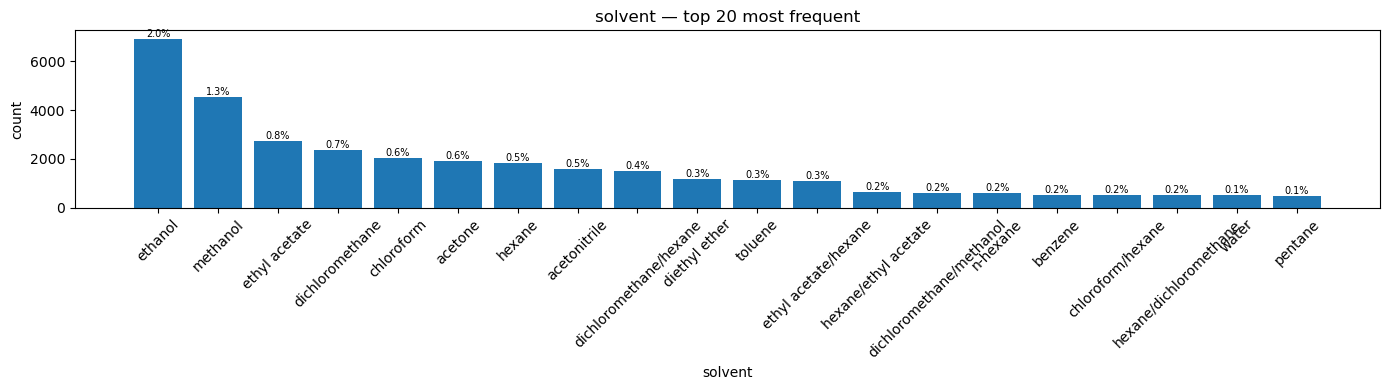

In [46]:
col = 'solvent'
print(f"Unique values : {df[col].nunique()}")
print(f"Missing       : {df[col].isna().sum():,} ({df[col].isna().mean()*100:.1f}%)\n")

top20 = df[col].value_counts().nlargest(20)
for val, count in top20.items():
    print(f"  {val:<35} {count:>9,} ({count/len(df)*100:.1f}%)")

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(top20.index, top20.values)
ax.set_title(f'{col} — top 20 most frequent')
ax.set_xlabel('solvent')
ax.set_ylabel('count')
ax.tick_params(axis='x', rotation=45)
for bar, val in zip(ax.patches, top20.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f'{val/len(df)*100:.1f}%', ha='center', va='bottom', fontsize=7)
plt.tight_layout()
plt.show()

## Free-text columns

### `disorder_details`

In [47]:
col = 'disorder_details'
print(f"Filled  : {df[col].notna().sum():,} ({df[col].notna().mean()*100:.1f}%)")
print(f"Unique  : {df[col].nunique():,}\n")
print("Examples:")
for ex in df[col].dropna().iloc[:3]:
    print(f"  — {ex[:120]}{'...' if len(ex) > 120 else ''}")

Filled  : 43,614 (12.9%)
Unique  : 35,195

Examples:
  — The cyclohexene ring is disordered over two sites with occupancies 0.5878:0.4122.
  — O4 and O4A disordered over two sites with occupancies 0.578:0.422.
  — A methyl group is disordered over two sites with occupancies 0.70:0.30.


### `polymorph`

In [48]:
col = 'polymorph'
print(f"Filled  : {df[col].notna().sum():,} ({df[col].notna().mean()*100:.1f}%)")
print(f"Unique  : {df[col].nunique():,}\n")

print("Top 20 most frequent values:")
for val, count in df[col].value_counts().head(20).items():
    print(f"  {count:>7,} ({count/df[col].notna().sum()*100:.1f}%)  {val}")

Filled  : 13,301 (3.9%)
Unique  : 1,198

Top 20 most frequent values:
    1,157 (8.7%)  polymorph I
      848 (6.4%)  monoclinic polymorph
      826 (6.2%)  alpha polymorph
      798 (6.0%)  polymorph II
      752 (5.7%)  orthorhombic polymorph
      714 (5.4%)  beta polymorph
      550 (4.1%)  P21/c polymorph
      390 (2.9%)  P21/n polymorph
      309 (2.3%)  triclinic polymorph
      270 (2.0%)  polymorph III
      258 (1.9%)  P-1 polymorph
      254 (1.9%)  polymorph 1
      214 (1.6%)  C2/c polymorph
      194 (1.5%)  gamma polymorph
      190 (1.4%)  polymorph 2
      185 (1.4%)  monoclinic P21/c polymorph
      144 (1.1%)  triclinic P-1 polymorph
      138 (1.0%)  polymorph A
      133 (1.0%)  Pbca polymorph
      124 (0.9%)  P212121 polymorph


### `phase_transition`

In [49]:
col = 'phase_transition'
print(f"Filled  : {df[col].notna().sum():,} ({df[col].notna().mean()*100:.1f}%)")
print(f"Unique  : {df[col].nunique():,}\n")
print("Examples:")
for ex in df[col].dropna().unique()[:5]:
    print(f"  — {ex[:120]}{'...' if len(ex) > 120 else ''}")

Filled  : 853 (0.3%)
Unique  : 435

Examples:
  — irreversible phase transition from partial cone to cone conformer on heating at 503 K
  — phase transition at 182deg.C from low-temperature to high-temperature phase
  — phase transition at 416.9 K with melting
  — phase transition at -65 deg.C
  — Order/disorder phase transition is at 208.6 K


### `bioactivity`

In [50]:
col = 'bioactivity'
print(f"Filled  : {df[col].notna().sum():,} ({df[col].notna().mean()*100:.1f}%)")
print(f"Unique  : {df[col].nunique():,}\n")
print("Examples:")
for ex in df[col].dropna().iloc[:5]:
    print(f"  — {ex[:120]}{'...' if len(ex) > 120 else ''}")

Filled  : 13,093 (3.9%)
Unique  : 7,362

Examples:
  — no marked cytotoxic activity towards K!562$ cells
  — biological activity
  — bosutinib is a second-generation tyrosine kinase inhibitor used in the treatment of chronic myelogenous leukaemia with r...
  — potential pharmacological activity
  — potential biological activity


## Cleaned columns

### `temperature` → `temperature_K`

In [51]:
raw, clean = 'temperature', 'temperature_K'

_QUAL_TEMP = ('low temperature', 'high temperature', 'room temperature',
              'ambient temperature', 'liquid nitrogen', 'low temp',
              'not reported', 'no temp reported')

n_raw   = df[raw].notna().sum()
n_clean = df[clean].notna().sum()

mask_empty       = df[raw].notna() & df[raw].map(lambda v: str(v).strip().lower() in ('nan','none','','?'))
mask_qualitative = df[raw].notna() & ~mask_empty & df[raw].map(lambda v: any(q in str(v).lower() for q in _QUAL_TEMP))
mask_true_loss   = df[raw].notna() & ~mask_empty & ~mask_qualitative & df[clean].isna()

print(f"Raw filled       : {n_raw:,} ({n_raw/len(df)*100:.1f}%)")
print(f"Parsed → {clean} : {n_clean:,} ({n_clean/n_raw*100:.1f}% of raw filled)")
print(f"\nBreakdown of unparsed (% of raw filled):")
print(f"  Empty/null strings           : {mask_empty.sum():>7,} ({mask_empty.sum()/n_raw*100:.1f}%)")
print(f"  Qualitative (unquantifiable) : {mask_qualitative.sum():>7,} ({mask_qualitative.sum()/n_raw*100:.1f}%)")
print(f"  Unexpected losses            : {mask_true_loss.sum():>7,} ({mask_true_loss.sum()/n_raw*100:.1f}%)")

print("\nFormat examples:")
formats = [
    ("'293 K'",              "→ 293.0 K"),
    ("'at 293 K'",           "→ 293.0 K"),
    ("'at -135 deg.C'",      "→ 138.15 K"),
    ("'240-260 K'",          "→ 250.0 K  (range midpoint)"),
    ("'at -50 to -70deg.C'", "→ 213.15 K (range midpoint)"),
    ("'at low temperature'", "→ None     (qualitative)"),
]
for fmt, result in formats:
    print(f"  {fmt:<25} {result}")

Raw filled       : 290,989 (85.8%)
Parsed → temperature_K : 290,972 (100.0% of raw filled)

Breakdown of unparsed (% of raw filled):
  Empty/null strings           :      13 (0.0%)
  Qualitative (unquantifiable) :       4 (0.0%)
  Unexpected losses            :       0 (0.0%)

Format examples:
  '293 K'                   → 293.0 K
  'at 293 K'                → 293.0 K
  'at -135 deg.C'           → 138.15 K
  '240-260 K'               → 250.0 K  (range midpoint)
  'at -50 to -70deg.C'      → 213.15 K (range midpoint)
  'at low temperature'      → None     (qualitative)


count    290972.00
mean        201.73
std          82.94
min           1.50
25%         120.00
50%         173.20
75%         293.00
max         773.00

Missing: 48,207 (14.2%)


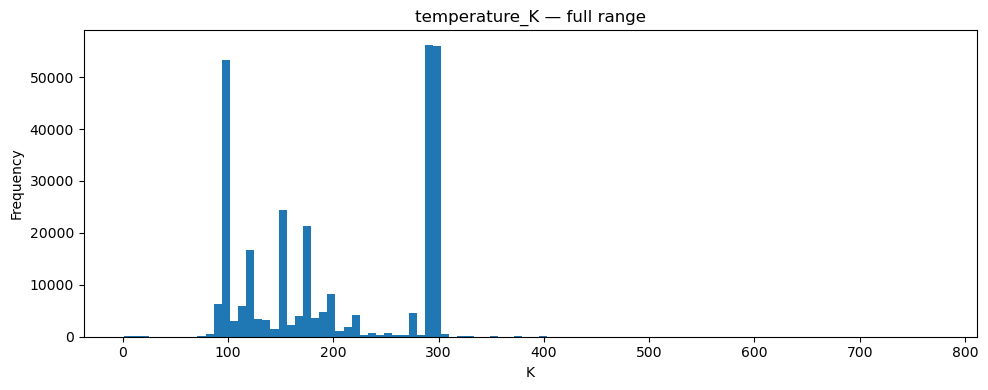

In [52]:
col = 'temperature_K'
s = df[col].dropna()

print(s.describe().round(2).to_string())
print(f"\nMissing: {df[col].isna().sum():,} ({df[col].isna().mean()*100:.1f}%)")

s.plot.hist(bins=100, figsize=(10, 4))
plt.title(f'{col} — full range')
plt.xlabel('K')
plt.tight_layout()
plt.show()

count    290972.00
mean        201.73
std          82.94
min           1.50
25%         120.00
50%         173.20
75%         293.00
max         773.00

99th percentile : 300.0 K
Values above p99 : 2,218 (0.76%)

Histogram peak  : 292.5 K  (19.4 °C)


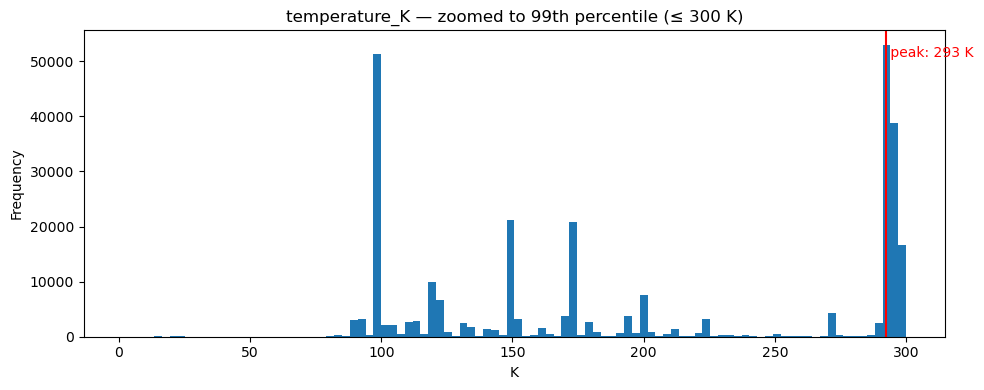

In [53]:
col = 'temperature_K'
s = df[col].dropna()

print(s.describe().round(2).to_string())

p99 = s.quantile(0.99)
print(f"\n99th percentile : {p99:.1f} K")
print(f"Values above p99 : {(s > p99).sum():,} ({(s > p99).mean()*100:.2f}%)")

s_zoom = s[s <= p99]
counts, edges = np.histogram(s_zoom, bins=100)
peak = (edges[counts.argmax()] + edges[counts.argmax() + 1]) / 2
print(f"\nHistogram peak  : {peak:.1f} K  ({peak - 273.15:.1f} °C)")

fig, ax = plt.subplots(figsize=(10, 4))
s_zoom.plot.hist(bins=100, ax=ax)
ax.axvline(peak, color='red', linewidth=1.5)
ax.text(peak, ax.get_ylim()[1] * 0.95, f' peak: {peak:.0f} K', color='red', va='top')
ax.set_title(f'{col} — zoomed to 99th percentile (≤ {p99:.0f} K)')
ax.set_xlabel('K')
plt.tight_layout()
plt.show()

### `melting_point` → `melting_point_k`

In [54]:
raw, clean = 'melting_point', 'melting_point_k'

_QUAL_MP = ('decompos', 'above', 'below', 'over', 'greater than', '>',
            'subl', '(sub.', 'approximately', 'about', 'around', 'ca.', 'less than')

n_raw   = df[raw].notna().sum()
n_clean = df[clean].notna().sum()

mask_empty       = df[raw].notna() & df[raw].map(lambda v: str(v).strip().lower() in ('nan','none','','?'))
mask_qualitative = df[raw].notna() & ~mask_empty & df[raw].map(lambda v: any(q in str(v).lower() for q in _QUAL_MP))
mask_true_loss   = df[raw].notna() & ~mask_empty & ~mask_qualitative & df[clean].isna()

print(f"Raw filled       : {n_raw:,} ({n_raw/len(df)*100:.1f}%)")
print(f"Parsed → {clean} : {n_clean:,} ({n_clean/n_raw*100:.1f}% of raw filled)")
print(f"\nBreakdown of unparsed (% of raw filled):")
print(f"  Empty/null strings           : {mask_empty.sum():>7,} ({mask_empty.sum()/n_raw*100:.1f}%)")
print(f"  Qualitative (unquantifiable) : {mask_qualitative.sum():>7,} ({mask_qualitative.sum()/n_raw*100:.1f}%)")
print(f"  Unexpected losses            : {mask_true_loss.sum():>7,} ({mask_true_loss.sum()/n_raw*100:.1f}%)")

print("\nFormat examples:")
formats = [
    ("'485 K'",               "→ 485.0 K"),
    ("'190-192 deg.C'",       "→ 464.15 K  (range midpoint)"),
    ("'327-328 K'",           "→ 327.5 K   (range midpoint)"),
    ("'72deg.C(dec.)'",       "→ 345.15 K  (with decomposition note)"),
    ("'558.0(1) K'",          "→ 558.0 K   (crystallographic uncertainty)"),
    ("'decomposes at 300 K'", "→ None       (qualitative)"),
    ("'above 400 K'",         "→ None       (qualitative)"),
]
for fmt, result in formats:
    print(f"  {fmt:<25} {result}")

Raw filled       : 77,977 (23.0%)
Parsed → melting_point_k : 74,670 (95.8% of raw filled)

Breakdown of unparsed (% of raw filled):
  Empty/null strings           :       0 (0.0%)
  Qualitative (unquantifiable) :   3,305 (4.2%)
  Unexpected losses            :       2 (0.0%)

Format examples:
  '485 K'                   → 485.0 K
  '190-192 deg.C'           → 464.15 K  (range midpoint)
  '327-328 K'               → 327.5 K   (range midpoint)
  '72deg.C(dec.)'           → 345.15 K  (with decomposition note)
  '558.0(1) K'              → 558.0 K   (crystallographic uncertainty)
  'decomposes at 300 K'     → None       (qualitative)
  'above 400 K'             → None       (qualitative)


count    74670.00
mean       423.58
std         61.34
min         67.00
25%        382.00
50%        420.00
75%        462.50
max       1438.15

Missing: 264,509 (78.0%)


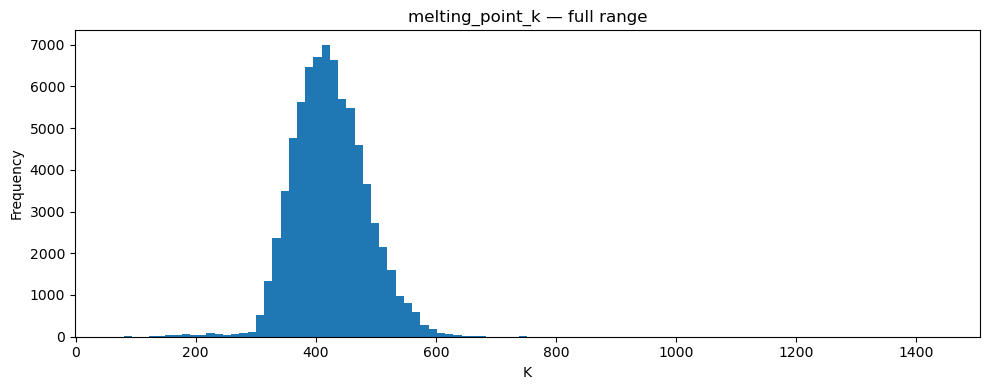

In [55]:
col = 'melting_point_k'
s = df[col].dropna()

print(s.describe().round(2).to_string())
print(f"\nMissing: {df[col].isna().sum():,} ({df[col].isna().mean()*100:.1f}%)")

s.plot.hist(bins=100, figsize=(10, 4))
plt.title(f'{col} — full range')
plt.xlabel('K')
plt.tight_layout()
plt.show()

count    74670.00
mean       423.58
std         61.34
min         67.00
25%        382.00
50%        420.00
75%        462.50
max       1438.15

99th percentile : 574.0 K
Values above p99 : 743 (1.00%)

Histogram peak  : 429.5 K  (156.4 °C)


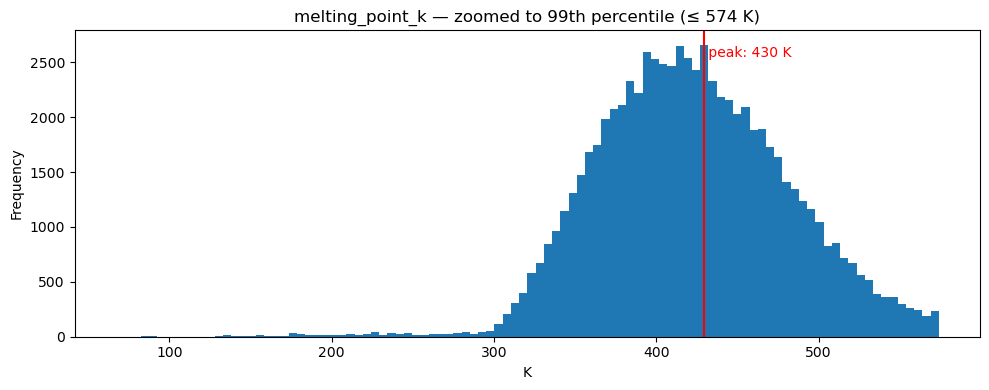

In [56]:
col = 'melting_point_k'
s = df[col].dropna()

print(s.describe().round(2).to_string())

p99 = s.quantile(0.99)
print(f"\n99th percentile : {p99:.1f} K")
print(f"Values above p99 : {(s > p99).sum():,} ({(s > p99).mean()*100:.2f}%)")

s_zoom = s[s <= p99]
counts, edges = np.histogram(s_zoom, bins=100)
peak = (edges[counts.argmax()] + edges[counts.argmax() + 1]) / 2
print(f"\nHistogram peak  : {peak:.1f} K  ({peak - 273.15:.1f} °C)")

fig, ax = plt.subplots(figsize=(10, 4))
s_zoom.plot.hist(bins=100, ax=ax)
ax.axvline(peak, color='red', linewidth=1.5)
ax.text(peak, ax.get_ylim()[1] * 0.95, f' peak: {peak:.0f} K', color='red', va='top')
ax.set_title(f'{col} — zoomed to 99th percentile (≤ {p99:.0f} K)')
ax.set_xlabel('K')
plt.tight_layout()
plt.show()

### `solvent` → `solvent_clean`

In [57]:
raw, clean = 'solvent', 'solvent_clean'

n_raw         = df[raw].notna().sum()
n_clean       = df[clean].notna().sum()
n_raw_unique  = df[raw].dropna().nunique()
mask_none     = df[raw].notna() & df[clean].isna()
n_none        = mask_none.sum()
n_none_unique = df.loc[mask_none, raw].nunique()

print(f"Raw filled        : {n_raw:,} ({n_raw/len(df)*100:.1f}%)")
print(f"Parsed → {clean} : {n_clean:,} ({n_clean/n_raw*100:.1f}% of raw filled)")
print(f"\nBreakdown of unparsed (% of raw filled):")
print(f"  Mapped to None (non-solvent / method) : {n_none:>7,} rows ({n_none/n_raw*100:.1f}%)  —  {n_none_unique:,} unique values ({n_none_unique/n_raw_unique*100:.1f}% of raw unique)")

print("\nFormat examples:")
formats = [
    ("'methanol/water'",        "→ 'methanol/water'"),
    ("'DCM'",                   "→ 'dichloromethane'"),
    ("'THF/EtOH (3:1)'",        "→ 'tetrahydrofuran/ethanol'"),
    ("'slow evaporation'",      "→ None  (non-solvent method)"),
    ("'by diffusion'",          "→ None  (technique, no solvent)"),
    ("'recrystallised'",        "→ None  (process, no solvent)"),
]
for fmt, result in formats:
    print(f"  {fmt:<28} {result}")

Raw filled        : 67,476 (19.9%)
Parsed → solvent_clean : 64,766 (96.0% of raw filled)

Breakdown of unparsed (% of raw filled):
  Mapped to None (non-solvent / method) :   2,710 rows (4.0%)  —  803 unique values (13.4% of raw unique)

Format examples:
  'methanol/water'             → 'methanol/water'
  'DCM'                        → 'dichloromethane'
  'THF/EtOH (3:1)'             → 'tetrahydrofuran/ethanol'
  'slow evaporation'           → None  (non-solvent method)
  'by diffusion'               → None  (technique, no solvent)
  'recrystallised'             → None  (process, no solvent)


Unique values : 1085
Missing       : 274,413 (80.9%)

  ethanol                                 7,906 (2.3%)
  methanol                                5,124 (1.5%)
  dichloromethane/hexane                  4,033 (1.2%)
  ethyl acetate/hexane                    3,506 (1.0%)
  ethyl acetate                           3,019 (0.9%)
  hexane                                  2,850 (0.8%)
  dichloromethane                         2,758 (0.8%)
  chloroform                              2,717 (0.8%)
  acetone                                 2,051 (0.6%)
  acetonitrile                            1,751 (0.5%)
  chloroform/hexane                       1,613 (0.5%)
  diethyl ether                           1,536 (0.5%)
  dichloromethane/methanol                1,275 (0.4%)
  toluene                                 1,218 (0.4%)
  ethyl acetate/petroleum ether           1,200 (0.4%)
  diethyl ether/hexane                      998 (0.3%)
  chloroform/methanol                       920 (0.3%)
  dichlorom

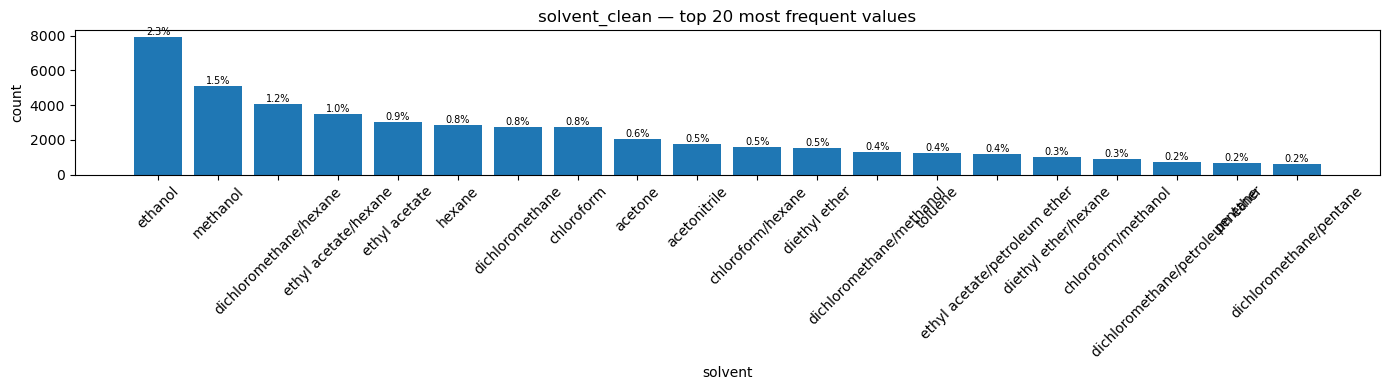

In [58]:
col = 'solvent_clean'
print(f"Unique values : {df[col].nunique()}")
print(f"Missing       : {df[col].isna().sum():,} ({df[col].isna().mean()*100:.1f}%)\n")

top20 = df[col].value_counts().nlargest(20)
for val, count in top20.items():
    print(f"  {val:<35} {count:>9,} ({count/len(df)*100:.1f}%)")

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(top20.index, top20.values)
ax.set_title(f'{col} — top 20 most frequent values')
ax.set_xlabel('solvent')
ax.set_ylabel('count')
ax.tick_params(axis='x', rotation=45)
for bar, val in zip(ax.patches, top20.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f'{val/len(df)*100:.1f}%', ha='center', va='bottom', fontsize=7)
plt.tight_layout()
plt.show()

Filled entries in solvent_clean  : 64,766
Total solvent component mentions : 93,565  (after splitting mixtures)
Unique individual solvents       : 218
  Solvent                       Count    % of components   % of entries
------------------------------------------------------------------------
  hexane                       14,995              16.0%          23.2%
  dichloromethane              12,080              12.9%          18.7%
  ethanol                      10,649              11.4%          16.4%
  ethyl acetate                 9,472              10.1%          14.6%
  methanol                      9,369              10.0%          14.5%
  chloroform                    7,029               7.5%          10.9%
  diethyl ether                 4,594               4.9%           7.1%
  acetone                       3,780               4.0%           5.8%
  petroleum ether               3,285               3.5%           5.1%
  acetonitrile                  2,672               2.9%

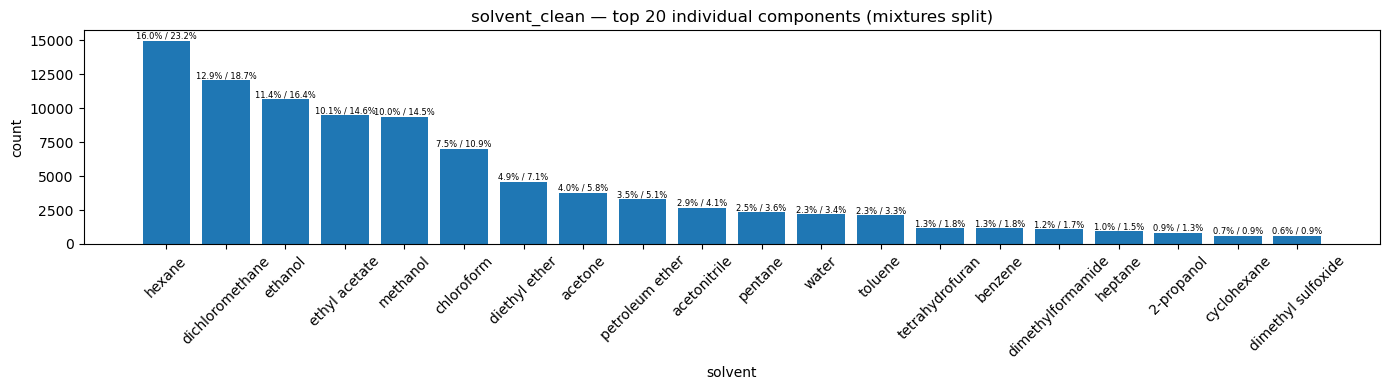

In [59]:
col = 'solvent_clean'

all_components = (
    df[col]
    .dropna()
    .str.split('/')
    .explode()
    .str.strip()
)

n_entries = df[col].notna().sum()
n_total   = len(all_components)
n_unique  = all_components.nunique()

print(f"Filled entries in solvent_clean  : {n_entries:,}")
print(f"Total solvent component mentions : {n_total:,}  (after splitting mixtures)")
print(f"Unique individual solvents       : {n_unique:,}")

top20 = all_components.value_counts().nlargest(20)

print(f"  {'Solvent':<25}  {'Count':>8}  {'% of components':>17}  {'% of entries':>13}")
print("-" * 72)
for val, count in top20.items():
    pct_comp    = count / n_total   * 100
    pct_entries = count / n_entries * 100
    print(f"  {val:<25}  {count:>8,}  {pct_comp:>16.1f}%  {pct_entries:>12.1f}%")

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(top20.index, top20.values)
ax.set_title(f"{col} — top 20 individual components (mixtures split)")
ax.set_xlabel("solvent")
ax.set_ylabel("count")
ax.tick_params(axis="x", rotation=45)
for bar, val in zip(ax.patches, top20.values):
    pct_comp    = val / n_total   * 100
    pct_entries = val / n_entries * 100
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f"{pct_comp:.1f}% / {pct_entries:.1f}%", ha="center", va="bottom", fontsize=6)
plt.tight_layout()
plt.show()

### `color` → `color_clean`

In [60]:
raw, clean = 'color', 'color_clean'

n_raw         = df[raw].notna().sum()
n_clean       = df[clean].notna().sum()
n_raw_unique  = df[raw].dropna().nunique()
mask_none     = df[raw].notna() & df[clean].isna()
n_none        = mask_none.sum()
n_none_unique = df.loc[mask_none, raw].nunique()

print(f"Raw filled         : {n_raw:,} ({n_raw/len(df)*100:.1f}%)")
print(f"Parsed → {clean}  : {n_clean:,} ({n_clean/n_raw*100:.1f}% of raw filled)")
print(f"\nMapped to None     : {n_none:>7,} rows ({n_none/n_raw*100:.1f}%)  —  {n_none_unique:,} unique values ({n_none_unique/n_raw_unique*100:.1f}% of raw unique)")

print("\nFormat examples:")
formats = [
    ("'pale yellow'",          "→ 'yellow'"),
    ("'bottle green'",         "→ 'green'"),
    ("'reddish'",              "→ 'red'"),
    ("'colorless to yellow'",  "→ 'colorless/yellow'"),
    ("'grey'",                 "→ 'gray'"),
    ("'violet'",               "→ 'purple'"),
    ("'multicoloured'",        "→ None  (no single base color)"),
    ("'tribochromic: ...'",    "→ None  (text description)"),
]
for fmt, result in formats:
    print(f"  {fmt:<30} {result}")

Raw filled         : 288,958 (85.2%)
Parsed → color_clean  : 288,955 (100.0% of raw filled)

Mapped to None     :       3 rows (0.0%)  —  2 unique values (0.2% of raw unique)

Format examples:
  'pale yellow'                  → 'yellow'
  'bottle green'                 → 'green'
  'reddish'                      → 'red'
  'colorless to yellow'          → 'colorless/yellow'
  'grey'                         → 'gray'
  'violet'                       → 'purple'
  'multicoloured'                → None  (no single base color)
  'tribochromic: ...'            → None  (text description)


Unique values : 99
Missing       : 50,224 (14.8%)

  colorless                             203,170 (59.9%)
  yellow                                 46,207 (13.6%)
  orange                                  9,191 (2.7%)
  red                                     8,595 (2.5%)
  white                                   7,960 (2.3%)
  brown                                   3,820 (1.1%)
  green                                   1,962 (0.6%)
  black                                   1,481 (0.4%)
  purple                                  1,314 (0.4%)
  blue                                      967 (0.3%)
  pink                                      581 (0.2%)
  orange/yellow                             462 (0.1%)
  colorless/white                           444 (0.1%)
  orange/red                                413 (0.1%)
  green/yellow                              251 (0.1%)
  gray                                      211 (0.1%)
  brown/red                                 208 (0.1%)
  gray/yello

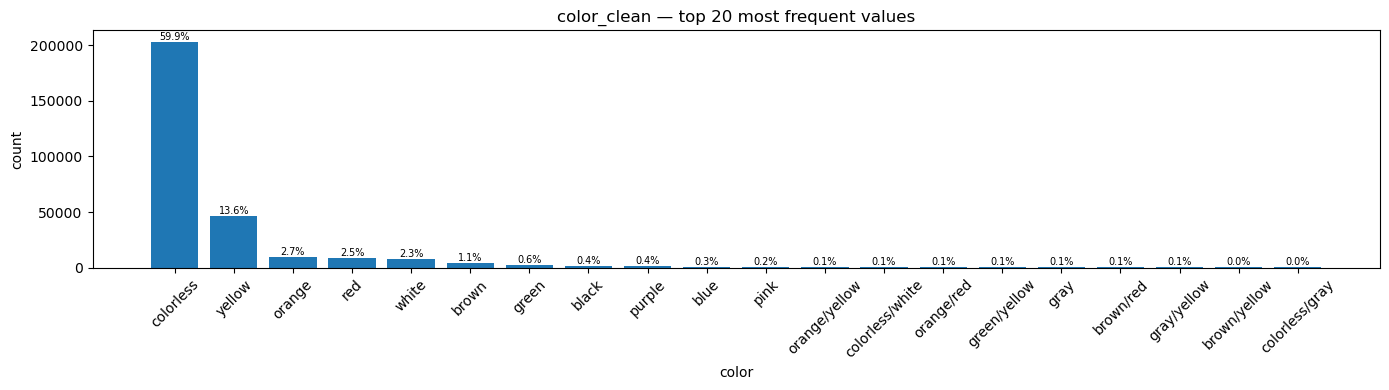

In [61]:
col = 'color_clean'
top = df[col].value_counts()
print(f"Unique values : {df[col].nunique()}")
print(f"Missing       : {df[col].isna().sum():,} ({df[col].isna().mean()*100:.1f}%)\n")
for val, count in top.head(200).items():
    print(f"  {val:<35} {count:>9,} ({count/len(df)*100:.1f}%)")

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(top.head(20).index, top.head(20).values)
ax.set_title(f'{col} — top 20 most frequent values')
ax.set_xlabel('color')
ax.set_ylabel('count')
ax.tick_params(axis='x', rotation=45)
for bar, val in zip(ax.patches, top.head(20).values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f'{val/len(df)*100:.1f}%', ha='center', va='bottom', fontsize=7)
plt.tight_layout()
plt.show()

Filled entries in color_clean    : 288,955
Total base color mentions        : 292,519  (after splitting compound colors)
Unique base colors               : 12

  Color               Count    % of components   % of entries
------------------------------------------------------------
  colorless         203,996              69.7%          70.6%
  yellow             47,584              16.3%          16.5%
  orange             10,198               3.5%           3.5%
  red                 9,502               3.2%           3.3%
  white               8,561               2.9%           3.0%
  brown               4,401               1.5%           1.5%
  green               2,375               0.8%           0.8%
  black               1,676               0.6%           0.6%
  purple              1,487               0.5%           0.5%
  blue                1,120               0.4%           0.4%
  gray                  980               0.3%           0.3%
  pink                  639        

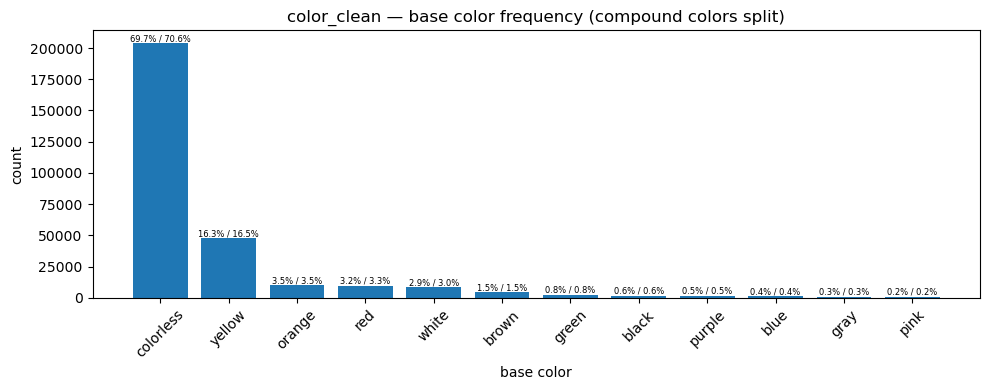

In [62]:
col = 'color_clean'

all_components = (
    df[col]
    .dropna()
    .str.split('/')
    .explode()
    .str.strip()
)

n_entries = df[col].notna().sum()
n_total   = len(all_components)
n_unique  = all_components.nunique()

print(f"Filled entries in color_clean    : {n_entries:,}")
print(f"Total base color mentions        : {n_total:,}  (after splitting compound colors)")
print(f"Unique base colors               : {n_unique:,}")

top = all_components.value_counts()

print(f"\n  {'Color':<15}  {'Count':>8}  {'% of components':>17}  {'% of entries':>13}")
print("-" * 60)
for val, count in top.items():
    pct_comp    = count / n_total   * 100
    pct_entries = count / n_entries * 100
    print(f"  {val:<15}  {count:>8,}  {pct_comp:>16.1f}%  {pct_entries:>12.1f}%")

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(top.index, top.values)
ax.set_title(f"{col} — base color frequency (compound colors split)")
ax.set_xlabel("base color")
ax.set_ylabel("count")
ax.tick_params(axis='x', rotation=45)
for bar, val in zip(ax.patches, top.values):
    pct_comp    = val / n_total   * 100
    pct_entries = val / n_entries * 100
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f"{pct_comp:.1f}% / {pct_entries:.1f}%", ha="center", va="bottom", fontsize=6)
plt.tight_layout()
plt.show()